<a href="https://colab.research.google.com/github/SANGHATI23/ohdsi-fhir-omop-showcase-demo/blob/main/FHIRy_pyOMOP_TFL_Execution_v8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FHIRy–pyOMOP Transformation Fidelity

FHIR R4 → FHIRy → pandas → TFL → pyOMOP → OMOP CDM

V0 is the single baseline. V1–V5 are controlled variants. The Transformation Fidelity Layer is stored as a sidecar and does not modify the OMOP schema.

# Phase A

## Environment

In [1]:
%pip -q install pyomop==6.4.0 fhiry==5.2.2 pyarrow scipy matplotlib tabulate nest-asyncio

import sys
import os
import json
import math
import time
import re
import ast
import hashlib
import uuid
import shutil
import sqlite3
import platform
import tempfile
import asyncio
from pathlib import Path
from collections import defaultdict
from enum import Enum

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import jensenshannon

import pyomop
import fhiry

print("Python:", sys.version.split()[0])
print("pyomop:", getattr(pyomop, "__version__", "unknown"))
print("fhiry:", getattr(fhiry, "__version__", "unknown"))
print("pandas:", pd.__version__)
print("numpy:", np.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.0/350.0 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.6/69.6 kB 6.0 MB/s eta 0:00:00


Python: 3.12.13
pyomop: 6.4.0
fhiry: 5.2.2
pandas: 2.2.2
numpy: 2.0.2


## Google Drive and repository

In [2]:
from google.colab import drive
drive.mount("/content/drive")

MYDRIVE = Path("/content/drive/MyDrive")

SOURCE_PATHS = {}
SOURCE_DF = {}

REPO_URL = "https://github.com/SANGHATI23/ohdsi-fhir-omop-showcase-demo.git"
REPO_DIR = Path("/content/ohdsi-fhir-omop-showcase-demo")

if REPO_DIR.exists():
    print("Repository:", REPO_DIR)
else:
    rc = os.system(f'git clone -q "{REPO_URL}" "{REPO_DIR}"')
    if rc != 0:
        raise RuntimeError("Repository clone failed.")

RUN_ROOT = MYDRIVE / "fhir_omop_colab" / "tfl_execution_v6"
NORMALIZED_DIR = RUN_ROOT / "normalized_sources"
DB_DIR = RUN_ROOT / "fresh_omop"
AUDIT_DIR = RUN_ROOT / "fidelity_audit"

for p in [RUN_ROOT, NORMALIZED_DIR, DB_DIR, AUDIT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

OUT_ROOT = REPO_DIR / "outputs"
MAPPING_OUT = OUT_ROOT / "mapping_summary"
FIDELITY_AUDIT_OUT = OUT_ROOT / "fidelity_audit"
FIDELITY_METRIC_OUT = OUT_ROOT / "fidelity_metrics"
ANALYTICAL_OUT = OUT_ROOT / "analytical_stability"
FIG_DIR = REPO_DIR / "figures"

for p in [
    MAPPING_OUT,
    FIDELITY_AUDIT_OUT,
    FIDELITY_METRIC_OUT,
    ANALYTICAL_OUT,
    FIG_DIR,
]:
    p.mkdir(parents=True, exist_ok=True)

print("Drive output:", RUN_ROOT)
print("Repository output:", OUT_ROOT)

Mounted at /content/drive
Drive output: /content/drive/MyDrive/fhir_omop_colab/tfl_execution_v6
Repository output: /content/ohdsi-fhir-omop-showcase-demo/outputs


In [3]:
def require_run_state(names, phase_name):
    missing = [name for name in names if name not in globals()]

    if missing:
        raise RuntimeError(
            f"{phase_name} requires earlier notebook state: "
            + ", ".join(missing)
            + ". Run the notebook from Phase A through this phase."
        )

## Source directories

In [4]:
SOURCE_NAME_PATTERNS = {
    "V0": [
        "V0_clinical_core_25k",
        "V0_clean_clinical_core_25k",
        "V0_baseline_clinical_core_25k",
    ],
    "V1": [
        "V1_missing_demographics_clinical_core_25k",
    ],
    "V2": [
        "V2_duplicate_encounter_ids_clinical_core_25k",
    ],
    "V3": [
        "V3_conflicting_codings_clinical_core_25k",
    ],
    "V4": [
        "V4_missing_medications_clinical_core_25k",
        "V4_medication_perturbation_clinical_core_25k",
    ],
    "V5": [
        "V5_missing_demographics_plus_conflicting_codings_clinical_core_25k",
        "V5_combined_clinical_core_25k",
    ],
}

def usable_source_path(path):
    path = Path(path)

    if path.is_file():
        return path.suffix.lower() in {".csv", ".parquet", ".pq", ".ndjson"}

    if path.is_dir():
        return bool(
            list(path.glob("*.ndjson"))
            or list(path.glob("*.csv"))
            or list(path.glob("*.parquet"))
            or list(path.glob("*.pq"))
        )

    return False


def discover_project_roots(root):
    root = Path(root)
    scores = defaultdict(int)

    anchor_names = (
        SOURCE_NAME_PATTERNS["V1"]
        + SOURCE_NAME_PATTERNS["V2"]
        + SOURCE_NAME_PATTERNS["V3"]
        + SOURCE_NAME_PATTERNS["V4"]
    )

    for name in anchor_names:
        for p in root.rglob(name):
            if usable_source_path(p):
                scores[p.parent] += 1

    return sorted(
        scores.items(),
        key=lambda x: (-x[1], str(x[0]))
    )


root_candidates = discover_project_roots(MYDRIVE)

project_root_table = pd.DataFrame([
    {
        "candidate_root": str(root),
        "matched_known_variant_directories": score,
    }
    for root, score in root_candidates
])

display(project_root_table)

if not root_candidates:
    raise FileNotFoundError(
        "No project root containing the known V1–V4 source directories was found."
    )

PROJECT_SOURCE_ROOT = root_candidates[0][0]

print("PROJECT_SOURCE_ROOT =", PROJECT_SOURCE_ROOT)
print("\nSibling entries:")
for p in sorted(PROJECT_SOURCE_ROOT.iterdir(), key=lambda x: x.name.lower()):
    print(" -", p.name)

,candidate_root,matched_known_variant_directories
0,/content/drive/MyDrive/MyDrive fhir_omop_colab,4


PROJECT_SOURCE_ROOT = /content/drive/MyDrive/MyDrive fhir_omop_colab 

Sibling entries:
 - V1_missing_demographics_clinical_core_25k
 - V1_missing_demographics_clinical_core_25k.tar.gz
 - V2_duplicate_encounter_ids_clinical_core_25k
 - V2_duplicate_encounter_ids_clinical_core_25k.tar.gz
 - V3_conflicting_codings_clinical_core_25k
 - V3_conflicting_codings_clinical_core_25k.tar.gz
 - V4_missing_medications_clinical_core_25k
 - V4_missing_medications_clinical_core_25k.tar.gz


In [5]:
def resolve_variant_source(project_root, variant):
    project_root = Path(project_root)

    exact = []
    for name in SOURCE_NAME_PATTERNS[variant]:
        p = project_root / name
        if usable_source_path(p):
            exact.append(p)

    if len(exact) == 1:
        return exact[0], "exact"

    if len(exact) > 1:
        return None, "multiple_exact"

    # Restricted fallback: search only inside the selected project root.
    prefix = variant.lower()
    fallback = []

    for p in project_root.iterdir():
        if not usable_source_path(p):
            continue

        low = p.name.lower()
        if low.startswith(prefix):
            fallback.append(p)

    if len(fallback) == 1:
        return fallback[0], "restricted_fallback"

    if len(fallback) > 1:
        return None, "multiple_fallback"

    return None, "not_found"


SOURCE_PATHS = globals().get("SOURCE_PATHS", {})
source_resolution_rows = []

for variant in ["V0", "V1", "V2", "V3", "V4", "V5"]:
    path, method = resolve_variant_source(PROJECT_SOURCE_ROOT, variant)

    if path is not None:
        SOURCE_PATHS[variant] = path

    source_resolution_rows.append({
        "variant": variant,
        "resolution": method,
        "path": str(path) if path else None,
    })

source_resolution = pd.DataFrame(source_resolution_rows)
display(source_resolution)

,variant,resolution,path
0,V0,not_found,None
1,V1,exact,/content/drive/MyDrive/MyDrive fhir_omop_colab...
2,V2,exact,/content/drive/MyDrive/MyDrive fhir_omop_colab...
3,V3,exact,/content/drive/MyDrive/MyDrive fhir_omop_colab...
4,V4,exact,/content/drive/MyDrive/MyDrive fhir_omop_colab...
5,V5,not_found,None


If a source has a different name, enter its exact path below. V0 can be loaded directly when available or recovered from verified unaffected domains in V1–V4. V5 can be recovered from the V1 Patient and V3 Condition changes when its original source is absent.

In [6]:
MANUAL_SOURCE_OVERRIDES = {
    # "V0": Path("/content/drive/MyDrive/..."),
    # "V1": Path("/content/drive/MyDrive/..."),
    # "V2": Path("/content/drive/MyDrive/..."),
    # "V3": Path("/content/drive/MyDrive/..."),
    # "V4": Path("/content/drive/MyDrive/..."),
    # "V5": Path("/content/drive/MyDrive/..."),
}

for variant, path in MANUAL_SOURCE_OVERRIDES.items():
    path = Path(path)

    if not usable_source_path(path):
        raise FileNotFoundError(
            f"{variant}: unusable source path: {path}"
        )

    SOURCE_PATHS[variant] = path


required_source_variants = ["V1", "V2", "V3", "V4"]

missing_required = [
    v for v in required_source_variants
    if v not in SOURCE_PATHS
]


print("Source map:")

for v in ["V0", "V1", "V2", "V3", "V4", "V5"]:
    print(v, "->", SOURCE_PATHS.get(v))


if missing_required:
    raise FileNotFoundError(
        "Missing required source variant(s): "
        + ", ".join(missing_required)
    )


if "V0" not in SOURCE_PATHS:
    print(
        "V0 source path not found. "
        "Phase B will recover V0 from verified unaffected domains in V1–V4."
    )

if "V5" not in SOURCE_PATHS:
    print(
        "V5 source path not found. "
        "Phase B will recover V5 from V0 + V1 Patient + V3 Condition."
    )

Source map:
V0 -> None
V1 -> /content/drive/MyDrive/MyDrive fhir_omop_colab /V1_missing_demographics_clinical_core_25k
V2 -> /content/drive/MyDrive/MyDrive fhir_omop_colab /V2_duplicate_encounter_ids_clinical_core_25k
V3 -> /content/drive/MyDrive/MyDrive fhir_omop_colab /V3_conflicting_codings_clinical_core_25k
V4 -> /content/drive/MyDrive/MyDrive fhir_omop_colab /V4_missing_medications_clinical_core_25k
V5 -> None
V0 source path not found. Phase B will recover V0 from verified unaffected domains in V1–V4.
V5 source path not found. Phase B will recover V5 from V0 + V1 Patient + V3 Condition.


# Phase B

## Normalize V0–V4

In [7]:
import fhiry.parallel as fp

FHIRY_CONFIG = {
    "REMOVE": ["text.div", "meta"],
    "RENAME": {},
}

RESOURCE_TYPE_CANDIDATES = [
    "resourceType",
    "resource.resourceType",
]

RESOURCE_ID_CANDIDATES = [
    "id",
    "resource.id",
    "resourceId",
    "resource.resourceId",
]


def first_existing_column(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c

    return None


def load_source_dataframe(path):
    path = Path(path)

    if path.is_dir():
        ndjson = sorted(path.glob("*.ndjson"))
        csvs = sorted(path.glob("*.csv"))
        parquets = sorted(
            list(path.glob("*.parquet"))
            + list(path.glob("*.pq"))
        )

        if ndjson:
            df = fp.ndjson(
                str(path),
                config_json=json.dumps(FHIRY_CONFIG)
            )

        elif len(csvs) == 1:
            df = pd.read_csv(
                csvs[0],
                low_memory=False
            )

        elif len(parquets) == 1:
            df = pd.read_parquet(
                parquets[0]
            )

        else:
            raise RuntimeError(
                f"Source directory {path} does not contain "
                "NDJSON or one unambiguous flat file."
            )

    elif path.suffix.lower() == ".ndjson":
        df = fp.ndjson(
            str(path.parent),
            config_json=json.dumps(FHIRY_CONFIG)
        )

    elif path.suffix.lower() == ".csv":
        df = pd.read_csv(
            path,
            low_memory=False
        )

    elif path.suffix.lower() in {
        ".parquet",
        ".pq",
    }:
        df = pd.read_parquet(
            path
        )

    else:
        raise ValueError(
            f"Unsupported source: {path}"
        )

    if df is None or len(df) == 0:
        raise ValueError(
            f"No rows produced from {path}"
        )

    rt_col = first_existing_column(
        df,
        RESOURCE_TYPE_CANDIDATES
    )

    id_col = first_existing_column(
        df,
        RESOURCE_ID_CANDIDATES
    )

    if rt_col is None:
        raise KeyError(
            f"FHIR resource type column not found for {path}"
        )

    out = df.copy()

    out["__tfl_resource_type"] = (
        out[rt_col].astype(str)
    )

    if id_col is None:
        out["__tfl_resource_id"] = pd.Series(
            [pd.NA] * len(out),
            dtype="string"
        )

    else:
        out["__tfl_resource_id"] = (
            out[id_col].astype("string")
        )

    out["__tfl_source_df_index"] = np.arange(
        len(out),
        dtype=np.int64
    )

    return out


SOURCE_DF = globals().get("SOURCE_DF", {})


variants_to_load = ["V1", "V2", "V3", "V4"]

if "V0" in SOURCE_PATHS:
    variants_to_load = ["V0"] + variants_to_load


for variant in variants_to_load:
    print("\n", "=" * 70)
    print(variant, SOURCE_PATHS[variant])

    df = load_source_dataframe(
        SOURCE_PATHS[variant]
    )

    SOURCE_DF[variant] = df

    normalized_path = (
        NORMALIZED_DIR
        / f"{variant}_normalized.parquet"
    )

    df.to_parquet(
        normalized_path,
        index=False
    )

    inventory = (
        df.groupby(
            "__tfl_resource_type",
            dropna=False
        )
        .size()
        .rename("rows")
        .reset_index()
        .sort_values(
            "rows",
            ascending=False
        )
    )

    print("Rows:", len(df))
    display(
        inventory.head(30)
    )


V1 /content/drive/MyDrive/MyDrive fhir_omop_colab /V1_missing_demographics_clinical_core_25k


Processing NDJSON files: 100%|██████████| 7/7 [06:19<00:00, 54.19s/it] 


Rows: 129333


,__tfl_resource_type,rows
0,Condition,25000
4,Observation,25000
3,MedicationRequest,25000
6,Procedure,25000
1,Medication,14131
2,MedicationAdministration,14131
5,Patient,1071



V2 /content/drive/MyDrive/MyDrive fhir_omop_colab /V2_duplicate_encounter_ids_clinical_core_25k


...

,__tfl_resource_type,rows
0,Condition,25000
4,Observation,25000
3,MedicationRequest,25000
6,Procedure,25000
1,Medication,14131
2,MedicationAdministration,14131
5,Patient,1071



V4 /content/drive/MyDrive/MyDrive fhir_omop_colab /V4_missing_medications_clinical_core_25k


Processing NDJSON files: 100%|██████████| 7/7 [06:19<00:00, 54.23s/it]


Rows: 126507


,__tfl_resource_type,rows
0,Condition,25000
4,Observation,25000
3,MedicationRequest,25000
6,Procedure,25000
1,Medication,12718
2,MedicationAdministration,12718
5,Patient,1071


## Baseline

In [8]:
def resource_subset(
    df,
    resource_type
):
    return df[
        df["__tfl_resource_type"]
        ==
        resource_type
    ].copy()


def normalize_compare_frame(
    df,
    resource_type,
    columns
):
    part = resource_subset(
        df,
        resource_type
    )

    if part.empty:
        return pd.DataFrame(
            columns=columns
        )

    work = part.reindex(
        columns=columns
    ).copy()

    for c in work.columns:
        work[c] = (
            work[c]
            .astype("string")
            .fillna("__MISSING__")
        )

    if "__tfl_resource_id" not in work.columns:
        raise KeyError(
            f"{resource_type}: resource ID not available."
        )

    ids = work[
        "__tfl_resource_id"
    ]

    if (
        ids.eq("__MISSING__").any()
        or ids.duplicated().any()
    ):
        raise ValueError(
            f"{resource_type}: missing or duplicate IDs "
            "prevent baseline recovery."
        )

    return (
        work.sort_values(
            "__tfl_resource_id",
            kind="stable"
        )
        .reset_index(drop=True)
    )


def resource_consensus_check(
    resource_type,
    donor_variants
):
    donors = [
        v
        for v in donor_variants
        if (
            v in SOURCE_DF
            and not resource_subset(
                SOURCE_DF[v],
                resource_type
            ).empty
        )
    ]

    if len(donors) < 2:
        raise ValueError(
            f"{resource_type}: fewer than two unaffected "
            "donor variants are available."
        )

    public_columns = sorted(
        set().union(*[
            {
                c
                for c in resource_subset(
                    SOURCE_DF[v],
                    resource_type
                ).columns
                if not c.startswith("__tfl_")
            }
            for v in donors
        ])
    )

    compare_columns = [
        "__tfl_resource_id"
    ] + public_columns

    base_variant = donors[0]

    base = normalize_compare_frame(
        SOURCE_DF[base_variant],
        resource_type,
        compare_columns
    )

    comparison_rows = []

    for variant in donors[1:]:
        other = normalize_compare_frame(
            SOURCE_DF[variant],
            resource_type,
            compare_columns
        )

        same_shape = base.shape == other.shape

        same_content = (
            same_shape
            and base.equals(other)
        )

        comparison_rows.append({
            "resource_type": resource_type,
            "reference_variant": base_variant,
            "comparison_variant": variant,
            "rows_reference": len(base),
            "rows_comparison": len(other),
            "identical": bool(same_content),
        })

        if not same_content:
            raise ValueError(
                f"{resource_type}: unaffected donor variants "
                f"{base_variant} and {variant} are not identical. "
                "V0 recovery stopped."
            )

    return (
        base_variant,
        comparison_rows
    )


MEDICATION_RESOURCE_TYPES = {
    "Medication",
    "MedicationRequest",
    "MedicationStatement",
    "MedicationAdministration",
    "Immunization",
}


def unaffected_donors_for_resource(
    resource_type
):
    if resource_type == "Patient":
        return ["V2", "V3", "V4"]

    if resource_type == "Encounter":
        return ["V1", "V3", "V4"]

    if resource_type == "Condition":
        return ["V1", "V2", "V4"]

    if resource_type in MEDICATION_RESOURCE_TYPES:
        return ["V1", "V2", "V3"]

    return ["V1", "V2", "V3", "V4"]


def recover_v0_from_unaffected_domains():
    all_resource_types = sorted(
        set().union(*[
            set(
                SOURCE_DF[v][
                    "__tfl_resource_type"
                ].astype(str)
            )
            for v in [
                "V1",
                "V2",
                "V3",
                "V4",
            ]
        ])
    )

    selected_parts = []
    consensus_rows = []

    for resource_type in all_resource_types:
        donors = unaffected_donors_for_resource(
            resource_type
        )

        donor_variant, checks = (
            resource_consensus_check(
                resource_type,
                donors
            )
        )

        consensus_rows.extend(
            checks
        )

        donor_part = resource_subset(
            SOURCE_DF[donor_variant],
            resource_type
        ).copy()

        selected_parts.append(
            donor_part
        )

    all_columns = sorted(
        set().union(*[
            set(part.columns)
            for part in selected_parts
        ])
    )

    selected_parts = [
        part.reindex(
            columns=all_columns
        )
        for part in selected_parts
    ]

    v0 = pd.concat(
        selected_parts,
        ignore_index=True
    )

    v0[
        "__tfl_source_df_index"
    ] = np.arange(
        len(v0),
        dtype=np.int64
    )

    consensus = pd.DataFrame(
        consensus_rows
    )

    return v0, consensus


if "V0" in SOURCE_DF:
    V0_ORIGIN = "original_source"
    v0_consensus = pd.DataFrame(
        columns=[
            "resource_type",
            "reference_variant",
            "comparison_variant",
            "rows_reference",
            "rows_comparison",
            "identical",
        ]
    )

else:
    SOURCE_DF["V0"], v0_consensus = (
        recover_v0_from_unaffected_domains()
    )

    V0_ORIGIN = (
        "recovered_from_verified_unaffected_"
        "V1_V2_V3_V4_domains"
    )

    recovered_v0_path = (
        NORMALIZED_DIR
        / "V0_recovered_normalized.parquet"
    )

    SOURCE_DF["V0"].to_parquet(
        recovered_v0_path,
        index=False
    )

    v0_consensus.to_csv(
        MAPPING_OUT
        / "v0_recovery_consensus_checks.csv",
        index=False
    )


v0_patients = resource_subset(
    SOURCE_DF["V0"],
    "Patient"
)


if len(v0_patients) != 1071:
    raise ValueError(
        "V0 must contain 1,071 Patient resources; "
        f"found {len(v0_patients)}."
    )


v0_patient_ids = set(
    v0_patients[
        "__tfl_resource_id"
    ]
    .dropna()
    .astype(str)
)


if len(v0_patient_ids) != 1071:
    raise ValueError(
        "V0 Patient resource IDs are missing or non-unique."
    )


print("V0 origin:", V0_ORIGIN)
print("V0 total rows:", len(SOURCE_DF["V0"]))
print("V0 Patient resources:", len(v0_patients))
print("V0 unique Patient IDs:", len(v0_patient_ids))

if len(v0_consensus):
    display(v0_consensus)

V0 origin: recovered_from_verified_unaffected_V1_V2_V3_V4_domains
V0 total rows: 129333
V0 Patient resources: 1071
V0 unique Patient IDs: 1071


,resource_type,reference_variant,comparison_variant,rows_reference,rows_comparison,identical
0,Condition,V1,V2,25000,25000,True
1,Condition,V1,V4,25000,25000,True
2,Medication,V1,V2,14131,14131,True
3,Medication,V1,V3,14131,14131,True
4,MedicationAdministration,V1,V2,14131,14131,True
5,MedicationAdministration,V1,V3,14131,14131,True
6,MedicationRequest,V1,V2,25000,25000,True
7,MedicationRequest,V1,V3,25000,25000,True
8,Observation,V1,V2,25000,25000,True
9,Observation,V1,V3,25000,25000,True


## V5

In [15]:
# FAST V5 construction
# V5 = V0 + V1 Patient perturbation + V3 Condition perturbation

SOURCE_DF = globals().get("SOURCE_DF", {})

required = ["V0", "V1", "V3"]

missing = [
    v for v in required
    if v not in SOURCE_DF
]

if missing:
    raise RuntimeError(
        "Missing normalized source dataframe(s): "
        + ", ".join(missing)
    )


def fast_replace_resource(base_df, donor_df, resource_type):
    """
    Replace one complete FHIR resource-type block in base_df
    with the corresponding block from donor_df.

    The source IDs must be identical.
    Original V0 row ordering is retained.
    """

    # Only the relevant resource blocks
    base_part = base_df.loc[
        base_df["__tfl_resource_type"] == resource_type
    ].copy()

    donor_part = donor_df.loc[
        donor_df["__tfl_resource_type"] == resource_type
    ].copy()

    print(
        f"{resource_type}: "
        f"V0 rows={len(base_part):,}, "
        f"donor rows={len(donor_part):,}"
    )

    # Validate IDs
    base_ids = (
        base_part["__tfl_resource_id"]
        .astype("string")
    )

    donor_ids = (
        donor_part["__tfl_resource_id"]
        .astype("string")
    )

    if base_ids.isna().any():
        raise ValueError(
            f"{resource_type}: V0 contains missing resource IDs."
        )

    if donor_ids.isna().any():
        raise ValueError(
            f"{resource_type}: donor contains missing resource IDs."
        )

    if base_ids.duplicated().any():
        raise ValueError(
            f"{resource_type}: V0 contains duplicate resource IDs."
        )

    if donor_ids.duplicated().any():
        raise ValueError(
            f"{resource_type}: donor contains duplicate resource IDs."
        )

    if set(base_ids.astype(str)) != set(donor_ids.astype(str)):
        raise ValueError(
            f"{resource_type}: donor resource IDs do not match V0."
        )

    # Preserve the exact V0 row positions
    order_map = (
        base_part[
            [
                "__tfl_resource_id",
                "__tfl_source_df_index"
            ]
        ]
        .copy()
    )

    order_map["__tfl_resource_id"] = (
        order_map["__tfl_resource_id"]
        .astype("string")
    )

    # Remove donor's old row index because V0 order is authoritative
    donor_part = donor_part.drop(
        columns=["__tfl_source_df_index"],
        errors="ignore"
    )

    donor_part["__tfl_resource_id"] = (
        donor_part["__tfl_resource_id"]
        .astype("string")
    )

    # Vectorized join: no Python row loop
    donor_part = donor_part.merge(
        order_map,
        on="__tfl_resource_id",
        how="left",
        validate="one_to_one"
    )

    if donor_part[
        "__tfl_source_df_index"
    ].isna().any():
        raise ValueError(
            f"{resource_type}: failed to recover V0 row positions."
        )

    # Everything except the block being replaced
    untouched = base_df.loc[
        base_df["__tfl_resource_type"] != resource_type
    ].copy()

    # Concatenate once
    result = pd.concat(
        [untouched, donor_part],
        ignore_index=True,
        sort=False
    )

    # Restore V0 ordering
    result = (
        result.sort_values(
            "__tfl_source_df_index",
            kind="stable"
        )
        .reset_index(drop=True)
    )

    # Re-establish clean sequential index
    result["__tfl_source_df_index"] = np.arange(
        len(result),
        dtype=np.int64
    )

    return result


print("Starting V5 construction...")

# Start from the recovered/original V0
v5 = SOURCE_DF["V0"].copy()

print("Initial V5 rows:", f"{len(v5):,}")

# V1 perturbation: Patient demographics
v5 = fast_replace_resource(
    v5,
    SOURCE_DF["V1"],
    "Patient"
)

print(
    "After Patient replacement:",
    f"{len(v5):,}"
)

# V3 perturbation: Condition coding
v5 = fast_replace_resource(
    v5,
    SOURCE_DF["V3"],
    "Condition"
)

print(
    "After Condition replacement:",
    f"{len(v5):,}"
)

SOURCE_DF["V5"] = v5

V5_ORIGIN = (
    "V0_with_V1_Patient_and_V3_Condition_rows"
)

# Save once
v5_path = (
    NORMALIZED_DIR
    / "V5_constructed_normalized.parquet"
)

SOURCE_DF["V5"].to_parquet(
    v5_path,
    index=False
)


# Checks
v0_n = len(SOURCE_DF["V0"])
v5_n = len(SOURCE_DF["V5"])

v5_patient_n = int(
    (
        SOURCE_DF["V5"]["__tfl_resource_type"]
        == "Patient"
    ).sum()
)

v5_condition_n = int(
    (
        SOURCE_DF["V5"]["__tfl_resource_type"]
        == "Condition"
    ).sum()
)


print("\nV5 COMPLETE")
print("V5 origin:", V5_ORIGIN)
print("V0 total rows:", f"{v0_n:,}")
print("V5 total rows:", f"{v5_n:,}")
print("V5 Patient rows:", f"{v5_patient_n:,}")
print("V5 Condition rows:", f"{v5_condition_n:,}")
print("Saved:", v5_path)


if v5_n != v0_n:
    raise ValueError(
        f"V5 row count changed: V0={v0_n:,}, V5={v5_n:,}"
    )

print("\nPASS: V5 retains the V0 total row count.")

Starting V5 construction...
Initial V5 rows: 129,333
Patient: V0 rows=1,071, donor rows=1,071
After Patient replacement: 129,333
Condition: V0 rows=25,000, donor rows=25,000
After Condition replacement: 129,333

V5 COMPLETE
V5 origin: V0_with_V1_Patient_and_V3_Condition_rows
V0 total rows: 129,333
V5 total rows: 129,333
V5 Patient rows: 1,071
V5 Condition rows: 25,000
Saved: /content/drive/MyDrive/fhir_omop_colab/tfl_execution_v6/normalized_sources/V5_constructed_normalized.parquet

PASS: V5 retains the V0 total row count.


## Variant checks

In [16]:
def missing_demographic_count(df):
    patient = resource_subset(df, "Patient")

    gender_col = first_existing_column(
        patient,
        ["gender", "resource.gender"]
    )

    birth_col = first_existing_column(
        patient,
        ["birthDate", "resource.birthDate"]
    )

    def missing_series(col):
        if col is None:
            return pd.Series(True, index=patient.index)

        s = patient[col]
        return (
            s.isna()
            | s.astype(str).str.strip().isin(["", "nan", "None", "<NA>"])
        )

    missing_gender = missing_series(gender_col)
    missing_birth = missing_series(birth_col)

    return int((missing_gender | missing_birth).sum())


def duplicate_resource_id_count(df, resource_type):
    part = resource_subset(df, resource_type)
    ids = part["__tfl_resource_id"].astype("string")
    valid = ids.notna() & (ids.astype(str).str.strip() != "")

    return int(ids.loc[valid].duplicated(keep=False).sum())


def coding_columns(df):
    return [
        c for c in df.columns
        if (
            "code" in c.lower()
            or "coding" in c.lower()
            or "system" in c.lower()
        )
        and not c.startswith("__tfl_")
    ]


def condition_coding_signature(df):
    part = resource_subset(df, "Condition")

    cols = coding_columns(part)

    if not cols:
        return pd.Series(dtype="string")

    sig = (
        part[cols]
        .fillna("")
        .astype(str)
        .agg("|".join, axis=1)
    )

    return sig


def medication_signature(df):
    med_types = [
        "MedicationRequest",
        "Medication",
        "MedicationStatement",
        "MedicationAdministration",
        "Immunization",
    ]

    part = df[df["__tfl_resource_type"].isin(med_types)].copy()

    cols = [
        c for c in part.columns
        if any(
            token in c.lower()
            for token in [
                "subject",
                "patient",
                "medication",
                "code",
                "reference",
                "status",
                "authored",
                "date",
            ]
        )
        and not c.startswith("__tfl_")
    ]

    if not cols:
        return pd.Series(dtype="string")

    return (
        part[cols]
        .fillna("")
        .astype(str)
        .agg("|".join, axis=1)
    )


variant_check_rows = []

v0_condition_sig = condition_coding_signature(SOURCE_DF["V0"])
v0_med_sig = medication_signature(SOURCE_DF["V0"])

for variant in ["V0", "V1", "V2", "V3", "V4", "V5"]:
    df = SOURCE_DF[variant]

    patient_ids = set(
        resource_subset(df, "Patient")["__tfl_resource_id"]
        .dropna()
        .astype(str)
    )

    condition_sig = condition_coding_signature(df)
    med_sig = medication_signature(df)

    variant_check_rows.append({
        "variant": variant,
        "patient_n": len(resource_subset(df, "Patient")),
        "same_patient_population_as_v0": patient_ids == v0_patient_ids,
        "missing_demographic_rows": missing_demographic_count(df),
        "duplicate_encounter_id_rows": duplicate_resource_id_count(df, "Encounter"),
        "condition_signature_unique": int(condition_sig.nunique()) if len(condition_sig) else 0,
        "medication_signature_unique": int(med_sig.nunique()) if len(med_sig) else 0,
    })

variant_checks = pd.DataFrame(variant_check_rows)
display(variant_checks)

if not variant_checks["same_patient_population_as_v0"].all():
    raise ValueError("V1–V5 do not all share the V0 Patient population.")

variant_checks.to_csv(
    MAPPING_OUT / "variant_source_checks.csv",
    index=False
)

,variant,patient_n,same_patient_population_as_v0,missing_demographic_rows,duplicate_encounter_id_rows,condition_signature_unique,medication_signature_unique
0,V0,1071,True,0,0,322,39166
1,V1,1071,True,161,0,322,39166
2,V2,1071,True,0,0,322,39166
3,V3,1071,True,0,0,508,39166
4,V4,1071,True,0,0,322,37754
5,V5,1071,True,161,0,508,39166


# Phase C

## TFL schema

In [17]:
class Fate(str, Enum):
    PRESERVED = "PRESERVED"
    NORMALIZED = "NORMALIZED"
    COLLAPSED = "COLLAPSED"
    AMBIGUOUS = "AMBIGUOUS"
    UNMAPPED = "UNMAPPED"
    DROPPED = "DROPPED"
    TRACEABILITY_LOSS = "TRACEABILITY_LOSS"


FATE_PRIORITY = {
    Fate.PRESERVED.value: 0,
    Fate.NORMALIZED.value: 1,
    Fate.COLLAPSED.value: 2,
    Fate.DROPPED.value: 3,
    Fate.AMBIGUOUS.value: 4,
    Fate.UNMAPPED.value: 5,
    Fate.TRACEABILITY_LOSS.value: 6,
}


WARNING_CODES = [
    "W_DEMOGRAPHIC_MISSING",
    "W_DUPLICATE_SOURCE_ID",
    "W_TRACEABILITY_LOSS",
    "W_CONFLICTING_CODING",
    "W_UNMAPPED_RESOURCE",
    "W_MEDICATION_ATTRIBUTION",
    "W_UNRESOLVED_REFERENCE",
]


def choose_fate(*statuses):
    values = []

    for status in statuses:
        if not status:
            continue

        if isinstance(status, Fate):
            values.append(status.value)
        else:
            values.append(str(status))

    if not values:
        return Fate.NORMALIZED.value

    return max(
        values,
        key=lambda x: FATE_PRIORITY.get(x, -1)
    )


TRANSFORMATION_VERSION = (
    "TFL-1.2"
    f"|pyomop-{getattr(pyomop, '__version__', 'unknown')}"
    f"|fhiry-{getattr(fhiry, '__version__', 'unknown')}"
)

print(TRANSFORMATION_VERSION)

TFL-1.2|pyomop-6.4.0|fhiry-5.2.2


In [18]:
PYOMOP_DIR = Path(pyomop.__file__).resolve().parent
MAPPING_PATH = PYOMOP_DIR / "mapping.default.json"

if not MAPPING_PATH.exists():
    raise FileNotFoundError(MAPPING_PATH)

with open(MAPPING_PATH, "r", encoding="utf-8") as f:
    PYOMOP_MAPPING = json.load(f)


def infer_resource_type(table_map):
    for flt in table_map.get("filters", []) or []:
        if (
            flt.get("column") in {"resourceType", "resource.resourceType"}
            and "equals" in flt
        ):
            return str(flt["equals"])

    return None


MAPPING_RULES = []

for ordinal, table_map in enumerate(
    PYOMOP_MAPPING.get("tables", []),
    start=1
):
    resource_type = infer_resource_type(table_map)

    if not resource_type:
        continue

    target_table = table_map["name"]

    MAPPING_RULES.append({
        "rule_order": ordinal,
        "source_resource_type": resource_type,
        "target_omop_table": target_table,
        "mapping_rule_id": f"{resource_type}_to_{target_table}_r{ordinal:02d}",
        "columns": table_map.get("columns", {}),
        "filters": table_map.get("filters", []),
    })


mapping_rules_df = pd.DataFrame([
    {
        "rule_order": r["rule_order"],
        "source_resource_type": r["source_resource_type"],
        "target_omop_table": r["target_omop_table"],
        "mapping_rule_id": r["mapping_rule_id"],
        "target_fields": "|".join(sorted(r["columns"].keys())),
        "source_paths": "|".join(sorted({
            v for v in r["columns"].values()
            if isinstance(v, str) and v
        })),
    }
    for r in MAPPING_RULES
])

display(mapping_rules_df)

mapping_rules_df.to_csv(
    MAPPING_OUT / "tfl_mapping_rules.csv",
    index=False
)

,rule_order,source_resource_type,target_omop_table,mapping_rule_id,target_fields,source_paths
0,1,Patient,person,Patient_to_person_r01,birth_datetime|ethnicity_concept_id|ethnicity_...,birthDate|extension|gender|patientId
1,2,Encounter,visit_occurrence,Encounter_to_visit_occurrence_r02,admitted_from_source_value|discharged_to_conce...,class.code|hospitalization.dischargeDispositio...
2,3,Condition,condition_occurrence,Condition_to_condition_occurrence_r03,condition_concept_id|condition_end_date|condit...,abatementDateTime|clinicalStatus.coding.codes|...
3,4,Procedure,procedure_occurrence,Procedure_to_procedure_occurrence_r04,modifier_concept_id|modifier_source_value|pers...,code.coding.codes|patientId|performedPeriod.en...
4,5,Device,device_exposure,Device_to_device_exposure_r05,device_concept_id|device_exposure_end_date|dev...,distinctIdentifier|expirationDate|manufactureD...
5,6,Observation,measurement,Observation_to_measurement_r06,measurement_concept_id|measurement_date|measur...,code.coding.codes|effectiveDateTime|issued|pat...
6,7,Observation,observation,Observation_to_observation_r07,observation_concept_id|observation_date|observ...,code.coding.codes|effectiveDateTime|issued|pat...
7,8,AllergyIntolerance,observation,AllergyIntolerance_to_observation_r08,observation_concept_id|observation_date|observ...,code.coding.codes|patientId|reaction|recordedDate
8,9,Immunization,drug_exposure,Immunization_to_drug_exposure_r09,drug_concept_id|drug_exposure_end_date|drug_ex...,occurrenceDateTime|patientId|vaccineCode.codin...
9,10,MedicationRequest,drug_exposure,MedicationRequest_to_drug_exposure_r10,drug_concept_id|drug_exposure_end_date|drug_ex...,authoredOn|dosageInstruction|medicationCodeabl...


In [19]:
fate_table = pd.DataFrame([
    ["PRESERVED", "Source information is represented without meaningful transformation-related loss."],
    ["NORMALIZED", "Source information is converted to a target-compatible representation."],
    ["COLLAPSED", "Multiple source representations are reduced to one retained representation."],
    ["AMBIGUOUS", "More than one competing source representation is present."],
    ["UNMAPPED", "No implemented target mapping is available within the declared mapping scope."],
    ["DROPPED", "Known source information is not retained by the configured transformation path."],
    ["TRACEABILITY_LOSS", "The target record cannot be linked uniquely to its source resource."],
], columns=["fidelity_status", "definition"])


warning_table = pd.DataFrame([
    ["W_DEMOGRAPHIC_MISSING", "Expected Patient demographic attribute absent at source or normalized output.", "V1,V5"],
    ["W_DUPLICATE_SOURCE_ID", "Repeated FHIR resource identifier within resource type.", "V2"],
    ["W_TRACEABILITY_LOSS", "Target record cannot be linked uniquely to source resource ID.", "V2"],
    ["W_CONFLICTING_CODING", "Multiple competing Condition coding representations detected.", "V3,V5"],
    ["W_UNMAPPED_RESOURCE", "FHIR resource type has no implemented pyOMOP mapping rule.", "Any"],
    ["W_MEDICATION_ATTRIBUTION", "Medication resource lacks deterministic patient/reference/status/date/code attribution.", "V4"],
    ["W_UNRESOLVED_REFERENCE", "FHIR reference cannot be resolved within the available source export.", "External"],
], columns=[
    "warning_code",
    "trigger",
    "expected_variant",
])


known_dropped_configuration = pd.DataFrame([
    {
        "source_path": "text.div",
        "fidelity_status": "DROPPED",
        "reason": "FHIRy normalization configuration",
    },
    {
        "source_path": "meta",
        "fidelity_status": "DROPPED",
        "reason": "FHIRy normalization configuration",
    },
])


display(fate_table)
display(warning_table)
display(known_dropped_configuration)

fate_table.to_csv(
    MAPPING_OUT / "tfl_information_fate_taxonomy.csv",
    index=False
)

warning_table.to_csv(
    MAPPING_OUT / "tfl_warning_rules.csv",
    index=False
)

known_dropped_configuration.to_csv(
    MAPPING_OUT / "tfl_known_dropped_configuration.csv",
    index=False
)

,fidelity_status,definition
0,PRESERVED,Source information is represented without mean...
1,NORMALIZED,Source information is converted to a target-co...
2,COLLAPSED,Multiple source representations are reduced to...
3,AMBIGUOUS,More than one competing source representation ...
4,UNMAPPED,No implemented target mapping is available wit...
5,DROPPED,Known source information is not retained by th...
6,TRACEABILITY_LOSS,The target record cannot be linked uniquely to...


,warning_code,trigger,expected_variant
0,W_DEMOGRAPHIC_MISSING,Expected Patient demographic attribute absent ...,"V1,V5"
1,W_DUPLICATE_SOURCE_ID,Repeated FHIR resource identifier within resou...,V2
2,W_TRACEABILITY_LOSS,Target record cannot be linked uniquely to sou...,V2
3,W_CONFLICTING_CODING,Multiple competing Condition coding representa...,"V3,V5"
4,W_UNMAPPED_RESOURCE,FHIR resource type has no implemented pyOMOP m...,Any
5,W_MEDICATION_ATTRIBUTION,Medication resource lacks deterministic patien...,V4
6,W_UNRESOLVED_REFERENCE,FHIR reference cannot be resolved within the a...,External


,source_path,fidelity_status,reason
0,text.div,DROPPED,FHIRy normalization configuration
1,meta,DROPPED,FHIRy normalization configuration


## Warning functions

In [20]:
def is_missing_value(value):
    if value is None:
        return True

    try:
        if pd.isna(value):
            return True
    except Exception:
        pass

    text = str(value).strip()

    return text == "" or text.lower() in {
        "nan",
        "none",
        "null",
        "<na>",
    }


def parse_multi_value(value):
    if is_missing_value(value):
        return []

    if isinstance(value, (list, tuple, set)):
        values = list(value)

    else:
        text = str(value).strip()
        values = None

        if (
            (text.startswith("[") and text.endswith("]"))
            or
            (text.startswith("(") and text.endswith(")"))
        ):
            try:
                parsed = ast.literal_eval(text)

                if isinstance(parsed, (list, tuple, set)):
                    values = list(parsed)

            except Exception:
                values = None

        if values is None:
            for sep in ["|", ";", ","]:
                if sep in text:
                    values = [x.strip() for x in text.split(sep)]
                    break

        if values is None:
            values = [text]

    return [
        str(x).strip().strip("'\"")
        for x in values
        if not is_missing_value(x)
    ]


def unique_nonempty(values):
    return sorted(set(
        str(x).strip()
        for x in values
        if not is_missing_value(x)
    ))


def row_first_value(row, candidates):
    for c in candidates:
        if c in row.index and not is_missing_value(row[c]):
            return row[c]

    return None


def duplicate_id_mask(df):
    ids = df["__tfl_resource_id"].astype("string")

    valid = (
        ids.notna()
        &
        (ids.astype(str).str.strip() != "")
    )

    keys = df.loc[
        valid,
        ["__tfl_resource_type", "__tfl_resource_id"]
    ].astype(str)

    dup = keys.duplicated(keep=False)

    out = pd.Series(False, index=df.index)
    out.loc[keys.index] = dup.values

    return out


def coding_profile(row):
    code_cols = [
        c for c in row.index
        if "code" in c.lower()
        and "display" not in c.lower()
        and not c.startswith("__tfl_")
    ]

    system_cols = [
        c for c in row.index
        if "system" in c.lower()
        and not c.startswith("__tfl_")
    ]

    codes = []
    systems = []

    for c in code_cols:
        codes.extend(parse_multi_value(row[c]))

    for c in system_cols:
        systems.extend(parse_multi_value(row[c]))

    return unique_nonempty(codes), unique_nonempty(systems)


def patient_reference_id(value):
    if is_missing_value(value):
        return None

    text = str(value).strip()

    if "/" in text:
        return text.rstrip("/").split("/")[-1]

    return text


def medication_attribution_warning(row, patient_ids):
    patient = row_first_value(
        row,
        [
            "patientId",
            "patient_id",
            "resource.patientId",
            "subject.reference",
            "resource.subject.reference",
        ]
    )

    code_value = row_first_value(
        row,
        [
            "medicationCodeableConcept.coding.codes",
            "medicationCodeableConcept.coding.code",
            "resource.medicationCodeableConcept.coding.codes",
            "resource.medicationCodeableConcept.coding.code",
            "code.coding.codes",
            "code.coding.code",
        ]
    )

    status = row_first_value(
        row,
        [
            "status",
            "resource.status",
        ]
    )

    event_date = row_first_value(
        row,
        [
            "authoredOn",
            "resource.authoredOn",
            "effectiveDateTime",
            "resource.effectiveDateTime",
            "occurrenceDateTime",
            "resource.occurrenceDateTime",
            "date",
            "resource.date",
        ]
    )

    patient_id = patient_reference_id(patient)

    unresolved_patient = (
        patient_id is not None
        and patient_id not in patient_ids
    )

    missing_required = (
        is_missing_value(patient)
        or is_missing_value(code_value)
        or is_missing_value(status)
        or is_missing_value(event_date)
    )

    return bool(unresolved_patient or missing_required)

# Phase D

## Audit records

In [21]:
def apply_mapping_filters(df, filters):
    if not filters:
        return df.copy()

    mask = pd.Series(True, index=df.index)

    for flt in filters:
        column = flt.get("column")

        if not column:
            continue

        actual = column

        if (
            actual not in df.columns
            and column in {"resourceType", "resource.resourceType"}
        ):
            actual = "__tfl_resource_type"

        if actual not in df.columns:
            continue

        series = df[actual]

        if "equals" in flt:
            mask &= series.astype(str) == str(flt["equals"])

        if "not_equals" in flt:
            mask &= series.astype(str) != str(flt["not_equals"])

        if "in" in flt:
            mask &= series.astype(str).isin(
                [str(x) for x in flt["in"]]
            )

        if flt.get("not_empty"):
            mask &= (
                series.notna()
                &
                (series.astype(str).str.strip() != "")
            )

        if flt.get("empty"):
            mask &= (
                series.isna()
                |
                (series.astype(str).str.strip() == "")
            )

    return df.loc[mask].copy()


def rule_source_paths(rule):
    return sorted({
        v for v in rule["columns"].values()
        if isinstance(v, str) and v
    })


def rule_target_fields(rule):
    return sorted(rule["columns"].keys())


def rule_default_fate(rule):
    has_source_value_target = any(
        str(target).endswith("_source_value")
        for target in rule["columns"].keys()
    )

    return (
        Fate.PRESERVED.value
        if has_source_value_target
        else Fate.NORMALIZED.value
    )


def transformation_id(
    variant,
    resource_type,
    resource_id,
    rule_id,
    source_df_index
):
    name = (
        f"{variant}|{resource_type}|{resource_id}|"
        f"{rule_id}|{source_df_index}|{TRANSFORMATION_VERSION}"
    )

    return str(
        uuid.uuid5(
            uuid.NAMESPACE_URL,
            name
        )
    )


def build_preload_audit(df, variant):
    duplicate_mask = duplicate_id_mask(df)

    patient_ids = set(
        resource_subset(df, "Patient")["__tfl_resource_id"]
        .dropna()
        .astype(str)
    )

    mapped_types = {
        r["source_resource_type"]
        for r in MAPPING_RULES
    }

    rows = []

    for rule in MAPPING_RULES:
        selected = apply_mapping_filters(
            df,
            rule["filters"]
        )

        source_paths = "|".join(rule_source_paths(rule))
        target_fields = "|".join(rule_target_fields(rule))

        for idx, row in selected.iterrows():
            rtype = str(row["__tfl_resource_type"])

            rid = row["__tfl_resource_id"]
            rid_text = None if is_missing_value(rid) else str(rid)

            warnings = []
            statuses = [rule_default_fate(rule)]

            if rid_text is None:
                warnings.append("W_TRACEABILITY_LOSS")
                statuses.append(Fate.TRACEABILITY_LOSS.value)

            if bool(duplicate_mask.loc[idx]):
                warnings.extend([
                    "W_DUPLICATE_SOURCE_ID",
                    "W_TRACEABILITY_LOSS",
                ])
                statuses.append(Fate.TRACEABILITY_LOSS.value)

            if rtype == "Patient":
                gender = row_first_value(
                    row,
                    ["gender", "resource.gender"]
                )

                birth = row_first_value(
                    row,
                    ["birthDate", "resource.birthDate"]
                )

                if is_missing_value(gender) or is_missing_value(birth):
                    warnings.append("W_DEMOGRAPHIC_MISSING")

            codes, systems = coding_profile(row)

            if rtype == "Condition":
                if len(codes) > 1:
                    statuses.append(Fate.COLLAPSED.value)

                if len(codes) > 1 or len(systems) > 1:
                    warnings.append("W_CONFLICTING_CODING")
                    statuses.append(Fate.AMBIGUOUS.value)

            if rtype in {
                "MedicationRequest",
                "MedicationStatement",
                "MedicationAdministration",
                "Immunization",
            }:
                if medication_attribution_warning(row, patient_ids):
                    warnings.append("W_MEDICATION_ATTRIBUTION")

            source_idx = int(row["__tfl_source_df_index"])

            rows.append({
                "transformation_id": transformation_id(
                    variant,
                    rtype,
                    rid_text,
                    rule["mapping_rule_id"],
                    source_idx
                ),
                "variant": variant,
                "source_resource_type": rtype,
                "source_resource_id": rid_text,
                "source_reference_or_path": source_paths,
                "source_value_or_code": None,
                "target_omop_table": rule["target_omop_table"],
                "target_omop_record_id": pd.NA,
                "target_omop_field": target_fields,
                "mapping_rule_id": rule["mapping_rule_id"],
                "fidelity_status": choose_fate(*statuses),
                "warning_code": "|".join(sorted(set(warnings))),
                "transformation_version": TRANSFORMATION_VERSION,
                "source_df_index": source_idx,
                "duplicate_source_id": bool(duplicate_mask.loc[idx]),
                "is_mapping_event": True,
                "target_link_method": None,
            })

    unsupported = df[
        ~df["__tfl_resource_type"].isin(mapped_types)
    ].copy()

    for idx, row in unsupported.iterrows():
        rtype = str(row["__tfl_resource_type"])
        rid = row["__tfl_resource_id"]
        rid_text = None if is_missing_value(rid) else str(rid)
        source_idx = int(row["__tfl_source_df_index"])

        rows.append({
            "transformation_id": transformation_id(
                variant,
                rtype,
                rid_text,
                "UNMAPPED_RESOURCE",
                source_idx
            ),
            "variant": variant,
            "source_resource_type": rtype,
            "source_resource_id": rid_text,
            "source_reference_or_path": None,
            "source_value_or_code": None,
            "target_omop_table": None,
            "target_omop_record_id": pd.NA,
            "target_omop_field": None,
            "mapping_rule_id": "UNMAPPED_RESOURCE",
            "fidelity_status": Fate.UNMAPPED.value,
            "warning_code": "W_UNMAPPED_RESOURCE",
            "transformation_version": TRANSFORMATION_VERSION,
            "source_df_index": source_idx,
            "duplicate_source_id": False,
            "is_mapping_event": False,
            "target_link_method": None,
        })

    return pd.DataFrame(rows)


PRELOAD_AUDIT = {}

for variant in ["V0", "V1", "V2", "V3", "V4", "V5"]:
    audit = build_preload_audit(
        SOURCE_DF[variant],
        variant
    )

    PRELOAD_AUDIT[variant] = audit

    print(
        variant,
        "audit rows=", len(audit),
        "mapping events=", int(audit["is_mapping_event"].sum()),
        "unmapped=", int((~audit["is_mapping_event"]).sum()),
    )

V0 audit rows= 154333 mapping events= 126071 unmapped= 28262
V1 audit rows= 154333 mapping events= 126071 unmapped= 28262
V2 audit rows= 154333 mapping events= 126071 unmapped= 28262
V3 audit rows= 154333 mapping events= 126071 unmapped= 28262
V4 audit rows= 151507 mapping events= 126071 unmapped= 25436
V5 audit rows= 154333 mapping events= 126071 unmapped= 28262


# Phase E

## Fresh OMOP databases

In [23]:
# ============================================================
# Phase E
# Fresh OMOP databases
# ============================================================

from pyomop import CdmEngineFactory
from pyomop.cdm54 import Base
from pyomop.loader import CdmCsvLoader
from pyomop.vocabulary import CdmVocabulary

import asyncio
import tempfile
from pathlib import Path

# Leave as None unless you have the Athena vocabulary folder.
ATHENA_VOCAB_DIR = None


# ------------------------------------------------------------
# Output databases
# ------------------------------------------------------------

DB_DIR = RUN_ROOT / "fresh_omop"
DB_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FRESH_DB = {
    variant: DB_DIR / f"{variant}_tfl.sqlite"
    for variant in [
        "V0",
        "V1",
        "V2",
        "V3",
        "V4",
        "V5",
    ]
}


# ------------------------------------------------------------
# Fresh pyOMOP transformation
# ------------------------------------------------------------

async def fresh_pyomop_load(
    df,
    db_path,
    vocab_dir=None
):
    db_path = Path(db_path)

    db_path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    # Always create a fresh OMOP database.
    if db_path.exists():
        db_path.unlink()

    print(
        "Creating:",
        db_path
    )

    # Configure SQLite database.
    cdm = CdmEngineFactory(
        db="sqlite",
        name=str(db_path)
    )

    try:

        # ----------------------------------------------------
        # IMPORTANT
        #
        # CdmEngineFactory creates the async engine lazily.
        # Accessing .engine initializes cdm._engine.
        # init_models() requires that engine to exist.
        # ----------------------------------------------------

        engine = cdm.engine

        if engine is None:
            raise RuntimeError(
                f"Could not initialize SQLite engine for {db_path}"
            )

        print(
            "Database engine initialized:",
            engine.url
        )

        # Create OMOP CDM 5.4 tables.
        await cdm.init_models(
            Base.metadata
        )

        print(
            "OMOP CDM tables initialized."
        )


        # ----------------------------------------------------
        # Optional Athena vocabulary
        # ----------------------------------------------------

        if vocab_dir is not None:

            vocab_dir = Path(
                vocab_dir
            )

            if not vocab_dir.exists():
                raise FileNotFoundError(
                    f"Athena vocabulary directory not found: "
                    f"{vocab_dir}"
                )

            vocabulary = CdmVocabulary(
                cdm,
                version="cdm54"
            )

            await vocabulary.create_vocab(
                str(vocab_dir)
            )

            print(
                "Vocabulary loaded."
            )


        # ----------------------------------------------------
        # pyOMOP CdmCsvLoader expects a CSV
        # ----------------------------------------------------

        with tempfile.NamedTemporaryFile(
            suffix=".csv",
            delete=False
        ) as tmp:

            temp_csv = Path(
                tmp.name
            )


        try:

            print(
                "Writing normalized FHIR dataframe:",
                f"{len(df):,}",
                "rows"
            )

            df.to_csv(
                temp_csv,
                index=False
            )


            loader = CdmCsvLoader(
                cdm,
                version="cdm54"
            )


            print(
                "Starting FHIR → OMOP mapping..."
            )


            await loader.load(
                csv_path=str(temp_csv),
                mapping_path=str(MAPPING_PATH),
                chunk_size=500
            )


            print(
                "FHIR → OMOP mapping complete."
            )


        finally:

            if temp_csv.exists():
                temp_csv.unlink()


    finally:

        await cdm.dispose()


    # --------------------------------------------------------
    # Final file check
    # --------------------------------------------------------

    if (
        not db_path.exists()
        or db_path.stat().st_size == 0
    ):
        raise RuntimeError(
            f"OMOP database was not created correctly: "
            f"{db_path}"
        )


    return db_path


# ------------------------------------------------------------
# Colab async helper
# ------------------------------------------------------------

def run_async(coro):

    try:

        loop = asyncio.get_event_loop()

        if loop.is_running():

            import nest_asyncio

            nest_asyncio.apply()

            return loop.run_until_complete(
                coro
            )

    except RuntimeError:
        pass


    return asyncio.run(
        coro
    )


# ------------------------------------------------------------
# Check that V0-V5 are already in memory
# ------------------------------------------------------------

required_variants = [
    "V0",
    "V1",
    "V2",
    "V3",
    "V4",
    "V5",
]

missing_variants = [
    variant
    for variant in required_variants
    if variant not in SOURCE_DF
]

if missing_variants:

    raise RuntimeError(
        "Missing normalized dataframe(s): "
        + ", ".join(
            missing_variants
        )
    )


print(
    "SOURCE_DF ready:",
    ", ".join(
        required_variants
    )
)


# ------------------------------------------------------------
# Transform V0-V5
# ------------------------------------------------------------

TRANSFORMATION_RUN = []


for variant in required_variants:

    print(
        "\n"
        + "=" * 70
    )

    print(
        "Transforming",
        variant
    )

    print(
        "Source rows:",
        f"{len(SOURCE_DF[variant]):,}"
    )


    start_time = time.perf_counter()


    db_path = run_async(
        fresh_pyomop_load(
            SOURCE_DF[variant],
            FRESH_DB[variant],
            vocab_dir=ATHENA_VOCAB_DIR
        )
    )


    elapsed = (
        time.perf_counter()
        -
        start_time
    )


    size_mb = (
        db_path.stat().st_size
        /
        (1024 ** 2)
    )


    TRANSFORMATION_RUN.append({
        "variant": variant,
        "source_rows": len(
            SOURCE_DF[variant]
        ),
        "database_path": str(
            db_path
        ),
        "database_mb": size_mb,
        "runtime_seconds": elapsed,
        "completed": True,
    })


    print(
        f"{variant} COMPLETE"
    )

    print(
        "Database:",
        db_path
    )

    print(
        "Database size:",
        f"{size_mb:.3f} MB"
    )

    print(
        "Runtime:",
        f"{elapsed:.2f} sec"
    )


transformation_run_summary = pd.DataFrame(
    TRANSFORMATION_RUN
)


print(
    "\n"
    + "=" * 70
)

print(
    "PHASE E COMPLETE"
)

display(
    transformation_run_summary
)


transformation_run_summary.to_csv(
    MAPPING_OUT
    / "fresh_omop_transformation_summary.csv",
    index=False
)

SOURCE_DF ready: V0, V1, V2, V3, V4, V5

Transforming V0
Source rows: 129,333
Creating: /content/drive/MyDrive/fhir_omop_colab/tfl_execution_v6/fresh_omop/V0_tfl.sqlite
Database engine initialized: sqlite+aiosqlite:////content/drive/MyDrive/fhir_omop_colab/tfl_execution_v6/fresh_omop/V0_tfl.sqlite
OMOP CDM tables initialized.
Writing normalized FHIR dataframe: 129,333 rows
Starting FHIR → OMOP mapping...
FHIR → OMOP mapping complete.
V0 COMPLETE
Database: /content/drive/MyDrive/fhir_omop_colab/tfl_execution_v6/fresh_omop/V0_tfl.sqlite
Database size: 23.430 MB
Runtime: 393.62 sec

Transforming V1
Source rows: 129,333
Creating: /content/drive/MyDrive/fhir_omop_colab/tfl_execution_v6/fresh_omop/V1_tfl.sqlite
Database engine initialized: sqlite+aiosqlite:////content/drive/MyDrive/fhir_omop_colab/tfl_execution_v6/fresh_omop/V1_tfl.sqlite
OMOP CDM tables initialized.
Writing normalized FHIR dataframe: 129,333 rows
Starting FHIR → OMOP mapping...
FHIR → OMOP mapping complete.
V1 COMPLETE
Data

,variant,source_rows,database_path,database_mb,runtime_seconds,completed
0,V0,129333,/content/drive/MyDrive/fhir_omop_colab/tfl_exe...,23.429688,393.624872,True
1,V1,129333,/content/drive/MyDrive/fhir_omop_colab/tfl_exe...,23.433594,394.471553,True
2,V2,129333,/content/drive/MyDrive/fhir_omop_colab/tfl_exe...,23.429688,392.364900,True
3,V3,129333,/content/drive/MyDrive/fhir_omop_colab/tfl_exe...,23.484375,393.906128,True
4,V4,126507,/content/drive/MyDrive/fhir_omop_colab/tfl_exe...,23.460938,395.017389,True
5,V5,129333,/content/drive/MyDrive/fhir_omop_colab/tfl_exe...,23.488281,396.074056,True


## Target IDs

In [24]:
def table_exists(conn, table):
    q = (
        "SELECT 1 FROM sqlite_master "
        "WHERE type='table' AND lower(name)=lower(?) LIMIT 1"
    )

    return conn.execute(q, (table,)).fetchone() is not None


def table_columns(conn, table):
    if not table_exists(conn, table):
        return []

    return [
        r[1]
        for r in conn.execute(
            f'PRAGMA table_info("{table}")'
        ).fetchall()
    ]


def primary_key_columns(conn, table):
    if not table_exists(conn, table):
        return []

    rows = conn.execute(
        f'PRAGMA table_info("{table}")'
    ).fetchall()

    return [
        r[1]
        for r in rows
        if int(r[5] or 0) > 0
    ]


def scalar(conn, sql, params=()):
    return conn.execute(sql, params).fetchone()[0]


def add_warning(existing, new_warning):
    values = {
        x
        for x in str(existing or "").split("|")
        if x and x != "nan"
    }

    values.add(new_warning)

    return "|".join(sorted(values))


def resolve_target_ids(audit, db_path):
    out = audit.copy()

    out["target_omop_record_id"] = pd.Series(
        [pd.NA] * len(out),
        dtype="Int64"
    )

    with sqlite3.connect(db_path) as conn:
        target_tables = sorted(
            set(
                out["target_omop_table"]
                .dropna()
                .astype(str)
            )
        )

        for table in target_tables:
            mask = (
                out["is_mapping_event"]
                &
                (out["target_omop_table"] == table)
            )

            event_rows = out.loc[mask]

            if event_rows.empty:
                continue

            if not table_exists(conn, table):
                failure = "TARGET_TABLE_MISSING"
                target_ids = None
            else:
                pks = primary_key_columns(conn, table)

                if len(pks) != 1:
                    failure = "PRIMARY_KEY_NOT_UNIQUE"
                    target_ids = None
                else:
                    pk = pks[0]

                    target_ids = [
                        int(r[0])
                        for r in conn.execute(
                            f'SELECT "{pk}" FROM "{table}" ORDER BY "{pk}"'
                        ).fetchall()
                    ]

                    failure = None

            if target_ids is None:
                for ix in event_rows.index:
                    out.at[ix, "warning_code"] = add_warning(
                        out.at[ix, "warning_code"],
                        "W_TRACEABILITY_LOSS"
                    )
                    out.at[ix, "fidelity_status"] = Fate.TRACEABILITY_LOSS.value
                    out.at[ix, "target_link_method"] = failure

                continue

            rules_for_table = [
                r for r in MAPPING_RULES
                if r["target_omop_table"] == table
            ]

            expected = sum(
                int(
                    (
                        event_rows["mapping_rule_id"]
                        ==
                        rule["mapping_rule_id"]
                    ).sum()
                )
                for rule in rules_for_table
            )

            if expected != len(target_ids):
                for ix in event_rows.index:
                    out.at[ix, "warning_code"] = add_warning(
                        out.at[ix, "warning_code"],
                        "W_TRACEABILITY_LOSS"
                    )
                    out.at[ix, "fidelity_status"] = Fate.TRACEABILITY_LOSS.value
                    out.at[ix, "target_link_method"] = "ROW_COUNT_RECONCILIATION_FAILED"

                continue

            cursor = 0

            for rule in rules_for_table:
                idxs = out.index[
                    out["is_mapping_event"]
                    &
                    (out["target_omop_table"] == table)
                    &
                    (out["mapping_rule_id"] == rule["mapping_rule_id"])
                ].tolist()

                ids = target_ids[
                    cursor:cursor + len(idxs)
                ]

                cursor += len(idxs)

                if len(ids) != len(idxs):
                    for ix in idxs:
                        out.at[ix, "warning_code"] = add_warning(
                            out.at[ix, "warning_code"],
                            "W_TRACEABILITY_LOSS"
                        )
                        out.at[ix, "fidelity_status"] = Fate.TRACEABILITY_LOSS.value
                        out.at[ix, "target_link_method"] = "RULE_SLICE_FAILED"

                    continue

                out.loc[
                    idxs,
                    "target_omop_record_id"
                ] = pd.array(ids, dtype="Int64")

                out.loc[
                    idxs,
                    "target_link_method"
                ] = "fresh_empty_db_verified_rule_source_order"

    invalid = (
        out["is_mapping_event"]
        &
        (
            out["source_resource_id"].isna()
            |
            out["duplicate_source_id"].fillna(False)
            |
            out["target_omop_record_id"].isna()
        )
    )

    for ix in out.index[invalid]:
        out.at[ix, "warning_code"] = add_warning(
            out.at[ix, "warning_code"],
            "W_TRACEABILITY_LOSS"
        )

        out.at[ix, "fidelity_status"] = choose_fate(
            out.at[ix, "fidelity_status"],
            Fate.TRACEABILITY_LOSS.value
        )

    return out


TFL_AUDIT = {}

for variant in ["V0", "V1", "V2", "V3", "V4", "V5"]:
    audit = resolve_target_ids(
        PRELOAD_AUDIT[variant],
        FRESH_DB[variant]
    )

    TFL_AUDIT[variant] = audit

    private_path = AUDIT_DIR / f"{variant}_fidelity_audit.parquet"
    audit.to_parquet(private_path, index=False)

    print(
        variant,
        "linked targets=",
        int(audit["target_omop_record_id"].notna().sum()),
        "/",
        int(audit["is_mapping_event"].sum())
    )

V0 linked targets= 126071 / 126071
V1 linked targets= 126071 / 126071
V2 linked targets= 126071 / 126071
V3 linked targets= 126071 / 126071
V4 linked targets= 126071 / 126071
V5 linked targets= 126071 / 126071


# Phase F

## Fidelity metrics

In [25]:
LOSS_STATUSES = {
    Fate.UNMAPPED.value,
    Fate.DROPPED.value,
    Fate.TRACEABILITY_LOSS.value,
}


def split_warning_codes(value):
    return [
        x for x in str(value or "").split("|")
        if x and x != "nan"
    ]


def metric_rows_for_audit(audit, variant):
    work = audit.copy()

    work["has_warning"] = work["warning_code"].apply(
        lambda x: len(split_warning_codes(x)) > 0
    )

    work["lineage_valid"] = (
        work["is_mapping_event"]
        &
        work["source_resource_id"].notna()
        &
        ~work["duplicate_source_id"].fillna(False)
        &
        work["target_omop_record_id"].notna()
    )

    work["mapped_target"] = (
        work["is_mapping_event"]
        &
        work["target_omop_record_id"].notna()
    )

    work["is_loss"] = work["fidelity_status"].isin(
        LOSS_STATUSES
    )

    work["is_ambiguity_or_warning"] = (
        (work["fidelity_status"] == Fate.AMBIGUOUS.value)
        |
        work["has_warning"]
    )

    rows = []

    mapped = work[work["is_mapping_event"]]

    rows.append({
        "variant": variant,
        "source_resource_type": "ALL",
        "target_omop_table": "ALL",
        "audit_items": len(work),
        "mapped_items": len(mapped),
        "lineage_coverage": (
            mapped["lineage_valid"].mean()
            if len(mapped) else np.nan
        ),
        "source_mapping_coverage": (
            work["mapped_target"].sum() / len(work)
            if len(work) else np.nan
        ),
        "transformation_loss_rate": (
            work["is_loss"].mean()
            if len(work) else np.nan
        ),
        "ambiguity_warning_rate": (
            work["is_ambiguity_or_warning"].mean()
            if len(work) else np.nan
        ),
    })

    for (rtype, table), sub in work.groupby(
        ["source_resource_type", "target_omop_table"],
        dropna=False
    ):
        sub_mapped = sub[sub["is_mapping_event"]]

        rows.append({
            "variant": variant,
            "source_resource_type": str(rtype),
            "target_omop_table": (
                str(table)
                if pd.notna(table)
                else "UNMAPPED"
            ),
            "audit_items": len(sub),
            "mapped_items": len(sub_mapped),
            "lineage_coverage": (
                sub_mapped["lineage_valid"].mean()
                if len(sub_mapped) else np.nan
            ),
            "source_mapping_coverage": (
                sub["mapped_target"].sum() / len(sub)
                if len(sub) else np.nan
            ),
            "transformation_loss_rate": (
                sub["is_loss"].mean()
                if len(sub) else np.nan
            ),
            "ambiguity_warning_rate": (
                sub["is_ambiguity_or_warning"].mean()
                if len(sub) else np.nan
            ),
        })

    return pd.DataFrame(rows)


fidelity_metrics = pd.concat(
    [
        metric_rows_for_audit(
            TFL_AUDIT[v],
            v
        )
        for v in ["V0", "V1", "V2", "V3", "V4", "V5"]
    ],
    ignore_index=True
)

display(
    fidelity_metrics[
        (fidelity_metrics["source_resource_type"] == "ALL")
        &
        (fidelity_metrics["target_omop_table"] == "ALL")
    ]
)

fidelity_metrics.to_csv(
    FIDELITY_METRIC_OUT / "tfl_primary_metrics.csv",
    index=False
)

,variant,source_resource_type,target_omop_table,audit_items,mapped_items,lineage_coverage,source_mapping_coverage,transformation_loss_rate,ambiguity_warning_rate
0,V0,ALL,ALL,154333,126071,1.0,0.816876,0.183124,0.407878
9,V1,ALL,ALL,154333,126071,1.0,0.816876,0.183124,0.408921
18,V2,ALL,ALL,154333,126071,1.0,0.816876,0.183124,0.407878
27,V3,ALL,ALL,154333,126071,1.0,0.816876,0.183124,0.407878
36,V4,ALL,ALL,151507,126071,1.0,0.832113,0.167887,0.397863
45,V5,ALL,ALL,154333,126071,1.0,0.816876,0.183124,0.408921


In [26]:
warning_rows = []

for variant, audit in TFL_AUDIT.items():
    for row in audit.itertuples():
        for warning in split_warning_codes(row.warning_code):
            warning_rows.append({
                "variant": variant,
                "source_resource_type": row.source_resource_type,
                "target_omop_table": row.target_omop_table,
                "warning_code": warning,
            })


warning_long = pd.DataFrame(warning_rows)

warning_counts = (
    warning_long.groupby(
        ["variant", "warning_code"],
        dropna=False
    )
    .size()
    .rename("warning_count")
    .reset_index()
)

audit_denominators = {
    v: len(TFL_AUDIT[v])
    for v in TFL_AUDIT
}

warning_counts["audit_items"] = warning_counts["variant"].map(
    audit_denominators
)

warning_counts["warning_rate"] = (
    warning_counts["warning_count"]
    /
    warning_counts["audit_items"]
)

display(warning_counts)

warning_counts.to_csv(
    FIDELITY_METRIC_OUT / "tfl_warning_counts_rates.csv",
    index=False
)

,variant,warning_code,warning_count,audit_items,warning_rate
0,V0,W_CONFLICTING_CODING,25000,154333,0.161987
1,V0,W_MEDICATION_ATTRIBUTION,9687,154333,0.062767
2,V0,W_UNMAPPED_RESOURCE,28262,154333,0.183124
3,V1,W_CONFLICTING_CODING,25000,154333,0.161987
4,V1,W_DEMOGRAPHIC_MISSING,161,154333,0.001043
5,V1,W_MEDICATION_ATTRIBUTION,9687,154333,0.062767
6,V1,W_UNMAPPED_RESOURCE,28262,154333,0.183124
7,V2,W_CONFLICTING_CODING,25000,154333,0.161987
8,V2,W_MEDICATION_ATTRIBUTION,9687,154333,0.062767
9,V2,W_UNMAPPED_RESOURCE,28262,154333,0.183124


## Controlled variants

In [27]:
EXPECTED_WARNINGS = {
    "V1": ["W_DEMOGRAPHIC_MISSING"],
    "V2": ["W_DUPLICATE_SOURCE_ID", "W_TRACEABILITY_LOSS"],
    "V3": ["W_CONFLICTING_CODING"],
    "V4": ["W_MEDICATION_ATTRIBUTION"],
    "V5": ["W_DEMOGRAPHIC_MISSING", "W_CONFLICTING_CODING"],
}


warning_lookup = {
    (r.variant, r.warning_code): (int(r.warning_count), float(r.warning_rate))
    for r in warning_counts.itertuples()
}


variant_validation_rows = []

for variant, expected in EXPECTED_WARNINGS.items():
    for warning in expected:
        v0_count, v0_rate = warning_lookup.get(
            ("V0", warning),
            (0, 0.0)
        )

        variant_count, variant_rate = warning_lookup.get(
            (variant, warning),
            (0, 0.0)
        )

        variant_validation_rows.append({
            "variant": variant,
            "expected_warning": warning,
            "v0_count": v0_count,
            "variant_count": variant_count,
            "delta_count": variant_count - v0_count,
            "v0_rate": v0_rate,
            "variant_rate": variant_rate,
            "delta_rate": variant_rate - v0_rate,
            "increased_vs_v0": variant_rate > v0_rate,
        })


variant_validation = pd.DataFrame(
    variant_validation_rows
)

display(variant_validation)

variant_validation.to_csv(
    FIDELITY_METRIC_OUT / "tfl_variant_warning_validation.csv",
    index=False
)

,variant,expected_warning,v0_count,variant_count,delta_count,v0_rate,variant_rate,delta_rate,increased_vs_v0
0,V1,W_DEMOGRAPHIC_MISSING,0,161,161,0.000000,0.001043,0.001043,True
1,V2,W_DUPLICATE_SOURCE_ID,0,0,0,0.000000,0.000000,0.000000,False
2,V2,W_TRACEABILITY_LOSS,0,0,0,0.000000,0.000000,0.000000,False
3,V3,W_CONFLICTING_CODING,25000,25000,0,0.161987,0.161987,0.000000,False
4,V4,W_MEDICATION_ATTRIBUTION,9687,9843,156,0.062767,0.064967,0.002200,True
5,V5,W_DEMOGRAPHIC_MISSING,0,161,161,0.000000,0.001043,0.001043,True
6,V5,W_CONFLICTING_CODING,25000,25000,0,0.161987,0.161987,0.000000,False


In [28]:
expected_by_variant = {
    v: set(warnings)
    for v, warnings in EXPECTED_WARNINGS.items()
}

unexpected_rows = []

for variant in ["V1", "V2", "V3", "V4", "V5"]:
    observed = warning_counts[
        warning_counts["variant"] == variant
    ]

    for row in observed.itertuples():
        v0_rate = warning_lookup.get(
            ("V0", row.warning_code),
            (0, 0.0)
        )[1]

        delta = float(row.warning_rate) - v0_rate

        if (
            row.warning_code not in expected_by_variant[variant]
            and delta > 0
        ):
            unexpected_rows.append({
                "variant": variant,
                "warning_code": row.warning_code,
                "delta_rate_vs_v0": delta,
            })


unexpected_warning_increases = pd.DataFrame(
    unexpected_rows,
    columns=[
        "variant",
        "warning_code",
        "delta_rate_vs_v0",
    ]
)

display(unexpected_warning_increases)

unexpected_warning_increases.to_csv(
    FIDELITY_METRIC_OUT / "tfl_unexpected_warning_increases.csv",
    index=False
)

,variant,warning_code,delta_rate_vs_v0
0,V4,W_CONFLICTING_CODING,0.003021


# Phase G

## Analytical checks

In [29]:
def get_person_ids(conn, table):
    if not table_exists(conn, table):
        return set()

    values = pd.read_sql_query(
        f'SELECT DISTINCT person_id FROM "{table}"',
        conn
    )["person_id"]

    return set(
        values.dropna().astype(int).tolist()
    )


def jaccard(a, b):
    a = set(a)
    b = set(b)

    if not (a | b):
        return 1.0

    return len(a & b) / len(a | b)


cohorts = {}

for variant, db_path in FRESH_DB.items():
    with sqlite3.connect(db_path) as conn:
        person = get_person_ids(conn, "person")
        condition = get_person_ids(conn, "condition_occurrence")
        drug = get_person_ids(conn, "drug_exposure")

    cohorts[variant] = {
        "person": person,
        "condition": condition,
        "drug": drug,
        "both": condition & drug,
    }


cohort_rows = []

for variant in ["V0", "V1", "V2", "V3", "V4", "V5"]:
    for cohort_name in ["condition", "drug", "both"]:
        base = cohorts["V0"][cohort_name]
        current = cohorts[variant][cohort_name]

        cohort_rows.append({
            "variant": variant,
            "cohort": cohort_name,
            "v0_n": len(base),
            "variant_n": len(current),
            "overlap": len(base & current),
            "union": len(base | current),
            "lost_from_v0": len(base - current),
            "gained_vs_v0": len(current - base),
            "jaccard_vs_v0": jaccard(base, current),
        })


cohort_summary = pd.DataFrame(cohort_rows)
display(cohort_summary)

cohort_summary.to_csv(
    ANALYTICAL_OUT / "cohort_jaccard_summary.csv",
    index=False
)

,variant,cohort,v0_n,variant_n,overlap,union,lost_from_v0,gained_vs_v0,jaccard_vs_v0
0,V0,condition,769,769,769,769,0,0,1.000000
1,V0,drug,609,609,609,609,0,0,1.000000
2,V0,both,609,609,609,609,0,0,1.000000
3,V1,condition,769,769,769,769,0,0,1.000000
4,V1,drug,609,609,609,609,0,0,1.000000
5,V1,both,609,609,609,609,0,0,1.000000
6,V2,condition,769,769,769,769,0,0,1.000000
7,V2,drug,609,609,609,609,0,0,1.000000
8,V2,both,609,609,609,609,0,0,1.000000
9,V3,condition,769,769,769,769,0,0,1.000000


In [30]:
prevalence_rows = []

for variant in ["V0", "V1", "V2", "V3", "V4", "V5"]:
    person_n = len(cohorts[variant]["person"])

    for cohort_name in ["condition", "drug", "both"]:
        n = len(cohorts[variant][cohort_name])

        prevalence_rows.append({
            "variant": variant,
            "cohort": cohort_name,
            "person_n": person_n,
            "cohort_n": n,
            "prevalence_percent": (
                100.0 * n / person_n
                if person_n else np.nan
            ),
        })


prevalence_summary = pd.DataFrame(prevalence_rows)

v0_prev = (
    prevalence_summary[
        prevalence_summary["variant"] == "V0"
    ][["cohort", "prevalence_percent"]]
    .rename(columns={
        "prevalence_percent": "v0_prevalence_percent"
    })
)

prevalence_summary = prevalence_summary.merge(
    v0_prev,
    on="cohort",
    how="left"
)

prevalence_summary["absolute_change_points"] = (
    prevalence_summary["prevalence_percent"]
    -
    prevalence_summary["v0_prevalence_percent"]
)

display(prevalence_summary)

prevalence_summary.to_csv(
    ANALYTICAL_OUT / "prevalence_summary.csv",
    index=False
)

,variant,cohort,person_n,cohort_n,prevalence_percent,v0_prevalence_percent,absolute_change_points
0,V0,condition,1071,769,71.802054,71.802054,0.000000
1,V0,drug,1071,609,56.862745,56.862745,0.000000
2,V0,both,1071,609,56.862745,56.862745,0.000000
3,V1,condition,1071,769,71.802054,71.802054,0.000000
4,V1,drug,1071,609,56.862745,56.862745,0.000000
5,V1,both,1071,609,56.862745,56.862745,0.000000
6,V2,condition,1071,769,71.802054,71.802054,0.000000
7,V2,drug,1071,609,56.862745,56.862745,0.000000
8,V2,both,1071,609,56.862745,56.862745,0.000000
9,V3,condition,1071,769,71.802054,71.802054,0.000000


In [31]:
def empirical_distribution(values):
    s = (
        pd.Series(values)
        .fillna("__MISSING__")
        .astype(str)
    )

    counts = s.value_counts()

    return counts / counts.sum()


def aligned_probabilities(a_values, b_values):
    pa = empirical_distribution(a_values)
    pb = empirical_distribution(b_values)

    idx = sorted(set(pa.index) | set(pb.index))

    return (
        pa.reindex(idx, fill_value=0).values,
        pb.reindex(idx, fill_value=0).values,
    )


def jsd(a_values, b_values):
    if len(a_values) == 0 or len(b_values) == 0:
        return np.nan

    p, q = aligned_probabilities(
        a_values,
        b_values
    )

    return float(
        jensenshannon(
            p,
            q,
            base=2
        ) ** 2
    )


def shannon_entropy(values):
    if len(values) == 0:
        return np.nan

    p = empirical_distribution(values).values

    return float(
        -(p * np.log2(p)).sum()
    )


def read_column(db_path, table, column):
    with sqlite3.connect(db_path) as conn:
        if not table_exists(conn, table):
            return []

        if column not in table_columns(conn, table):
            return []

        return (
            pd.read_sql_query(
                f'SELECT "{column}" FROM "{table}"',
                conn
            )[column]
            .fillna("__MISSING__")
            .astype(str)
            .tolist()
        )


DIST_FIELDS = {
    "gender": ("person", "gender_concept_id"),
    "condition_source": ("condition_occurrence", "condition_source_value"),
    "drug_source": ("drug_exposure", "drug_source_value"),
}


distribution_rows = []

for label, (table, column) in DIST_FIELDS.items():
    v0_values = read_column(
        FRESH_DB["V0"],
        table,
        column
    )

    v0_entropy = shannon_entropy(v0_values)

    for variant in ["V0", "V1", "V2", "V3", "V4", "V5"]:
        values = read_column(
            FRESH_DB[variant],
            table,
            column
        )

        distribution_rows.append({
            "field": label,
            "variant": variant,
            "rows": len(values),
            "unique_values": len(set(values)),
            "jsd_vs_v0": jsd(v0_values, values),
            "entropy_bits": shannon_entropy(values),
            "entropy_change_bits": (
                shannon_entropy(values)
                -
                v0_entropy
            ),
        })


distribution_summary = pd.DataFrame(
    distribution_rows
)

display(distribution_summary)

distribution_summary.to_csv(
    ANALYTICAL_OUT / "distribution_entropy_summary.csv",
    index=False
)

,field,variant,rows,unique_values,jsd_vs_v0,entropy_bits,entropy_change_bits
0,gender,V0,1071,2,0.000000,0.999396,0.000000
1,gender,V1,1071,3,0.079577,1.459664,0.460269
2,gender,V2,1071,2,0.000000,0.999396,0.000000
3,gender,V3,1071,2,0.000000,0.999396,0.000000
4,gender,V4,1071,2,0.000000,0.999396,0.000000
5,gender,V5,1071,3,0.079577,1.459664,0.460269
6,condition_source,V0,25000,247,0.000000,5.337112,0.000000
7,condition_source,V1,25000,247,0.000000,5.337112,0.000000
8,condition_source,V2,25000,247,0.000000,5.337112,0.000000
9,condition_source,V3,25000,412,0.052355,5.800965,0.463853


## Bootstrap JSD

In [32]:
BOOTSTRAP_REPS = 500
RNG = np.random.default_rng(20260815)


def bootstrap_jsd_null(values, reps=500):
    values = np.asarray(
        pd.Series(values)
        .fillna("__MISSING__")
        .astype(str)
        .tolist(),
        dtype=object
    )

    n = len(values)

    if n == 0:
        return np.array([])

    stats = np.empty(reps, dtype=float)

    for i in range(reps):
        a = values[
            RNG.integers(0, n, size=n)
        ]

        b = values[
            RNG.integers(0, n, size=n)
        ]

        stats[i] = jsd(a, b)

    return stats


bootstrap_rows = []

for label, (table, column) in DIST_FIELDS.items():
    v0_values = read_column(
        FRESH_DB["V0"],
        table,
        column
    )

    null_stats = bootstrap_jsd_null(
        v0_values,
        BOOTSTRAP_REPS
    )

    p95 = (
        float(np.quantile(null_stats, 0.95))
        if len(null_stats)
        else np.nan
    )

    for variant in ["V1", "V2", "V3", "V4", "V5"]:
        values = read_column(
            FRESH_DB[variant],
            table,
            column
        )

        observed = jsd(
            v0_values,
            values
        )

        bootstrap_rows.append({
            "field": label,
            "variant": variant,
            "observed_jsd": observed,
            "null_p95_jsd": p95,
            "above_null_p95": (
                observed > p95
                if not np.isnan(p95)
                else np.nan
            ),
            "bootstrap_reps": BOOTSTRAP_REPS,
        })


bootstrap_summary = pd.DataFrame(
    bootstrap_rows
)

display(bootstrap_summary)

bootstrap_summary.to_csv(
    ANALYTICAL_OUT / "bootstrap_jsd_summary.csv",
    index=False
)

,field,variant,observed_jsd,null_p95_jsd,above_null_p95,bootstrap_reps
0,gender,V1,0.079577,0.001164,True,500
1,gender,V2,0.000000,0.001164,False,500
2,gender,V3,0.000000,0.001164,False,500
3,gender,V4,0.000000,0.001164,False,500
4,gender,V5,0.079577,0.001164,True,500
5,condition_source,V1,0.000000,0.004263,False,500
6,condition_source,V2,0.000000,0.004263,False,500
7,condition_source,V3,0.052355,0.004263,True,500
8,condition_source,V4,0.000000,0.004263,False,500
9,condition_source,V5,0.052355,0.004263,True,500


## Temporal integrity

In [33]:
TEMPORAL_SPECS = {
    "condition_occurrence": (
        "condition_start_date",
        "condition_end_date",
    ),
    "drug_exposure": (
        "drug_exposure_start_date",
        "drug_exposure_end_date",
    ),
    "visit_occurrence": (
        "visit_start_date",
        "visit_end_date",
    ),
    "observation": (
        "observation_date",
        None,
    ),
    "measurement": (
        "measurement_date",
        None,
    ),
    "procedure_occurrence": (
        "procedure_date",
        None,
    ),
}


temporal_rows = []

for variant, db_path in FRESH_DB.items():
    with sqlite3.connect(db_path) as conn:
        for table, (start_col, end_col) in TEMPORAL_SPECS.items():
            if not table_exists(conn, table):
                continue

            cols = set(table_columns(conn, table))

            if start_col not in cols:
                continue

            total = scalar(
                conn,
                f'SELECT COUNT(*) FROM "{table}"'
            )

            missing_start = scalar(
                conn,
                f'SELECT COUNT(*) FROM "{table}" WHERE "{start_col}" IS NULL'
            )

            invalid_order = 0

            if end_col and end_col in cols:
                invalid_order = scalar(
                    conn,
                    f'''
                    SELECT COUNT(*)
                    FROM "{table}"
                    WHERE "{start_col}" IS NOT NULL
                      AND "{end_col}" IS NOT NULL
                      AND DATE("{start_col}") > DATE("{end_col}")
                    '''
                )

            temporal_rows.append({
                "variant": variant,
                "table": table,
                "rows": total,
                "missing_start": missing_start,
                "start_after_end": invalid_order,
            })


temporal_summary = pd.DataFrame(
    temporal_rows
)

display(temporal_summary)

temporal_summary.to_csv(
    ANALYTICAL_OUT / "temporal_integrity_summary.csv",
    index=False
)

,variant,table,rows,missing_start,start_after_end
0,V0,condition_occurrence,25000,0,0
1,V0,drug_exposure,25000,0,0
2,V0,visit_occurrence,0,0,0
3,V0,observation,25000,0,0
4,V0,measurement,25000,0,0
5,V0,procedure_occurrence,25000,0,0
6,V1,condition_occurrence,25000,0,0
7,V1,drug_exposure,25000,0,0
8,V1,visit_occurrence,0,0,0
9,V1,observation,25000,0,0


## Runtime and database size

In [34]:
QUERY_SET = {
    "persons": "SELECT COUNT(*) FROM person",
    "condition_persons": "SELECT COUNT(DISTINCT person_id) FROM condition_occurrence",
    "drug_persons": "SELECT COUNT(DISTINCT person_id) FROM drug_exposure",
    "condition_source_summary": "SELECT condition_source_value, COUNT(*) FROM condition_occurrence GROUP BY condition_source_value",
    "condition_drug_overlap": (
        "SELECT COUNT(*) FROM ("
        "SELECT DISTINCT person_id FROM condition_occurrence "
        "INTERSECT "
        "SELECT DISTINCT person_id FROM drug_exposure"
        ")"
    ),
}


runtime_rows = []

for variant, db_path in FRESH_DB.items():
    with sqlite3.connect(db_path) as conn:
        for query_name, sql in QUERY_SET.items():
            for repetition in range(1, 6):
                start = time.perf_counter()
                conn.execute(sql).fetchall()
                elapsed = time.perf_counter() - start

                runtime_rows.append({
                    "variant": variant,
                    "query": query_name,
                    "repetition": repetition,
                    "seconds": elapsed,
                })


runtime_long = pd.DataFrame(runtime_rows)

runtime_summary = (
    runtime_long.groupby(
        ["variant", "query"]
    )["seconds"]
    .agg(["mean", "median", "min", "max", "std"])
    .reset_index()
)


database_size = pd.DataFrame([
    {
        "variant": variant,
        "database_mb": (
            path.stat().st_size / (1024 ** 2)
        ),
    }
    for variant, path in FRESH_DB.items()
])


display(runtime_summary)
display(database_size)

runtime_long.to_csv(
    ANALYTICAL_OUT / "query_runtime_long.csv",
    index=False
)

runtime_summary.to_csv(
    ANALYTICAL_OUT / "query_runtime_summary.csv",
    index=False
)

database_size.to_csv(
    ANALYTICAL_OUT / "database_size_summary.csv",
    index=False
)

,variant,query,mean,median,min,max,std
0,V0,condition_drug_overlap,0.008435,0.008319,0.008290,0.008784,0.000207
1,V0,condition_persons,0.002343,0.001456,0.001404,0.005896,0.001986
2,V0,condition_source_summary,0.015936,0.014590,0.013920,0.021912,0.003363
3,V0,drug_persons,0.002673,0.001689,0.001602,0.006629,0.002212
4,V0,persons,0.000985,0.000295,0.000264,0.003708,0.001523
5,V1,condition_drug_overlap,0.008366,0.008319,0.008188,0.008717,0.000205
6,V1,condition_persons,0.002796,0.001504,0.001425,0.008112,0.002972
7,V1,condition_source_summary,0.015285,0.013875,0.013798,0.020665,0.003014
8,V1,drug_persons,0.002680,0.001466,0.001403,0.007657,0.002783
9,V1,persons,0.001007,0.000222,0.000214,0.004105,0.001732


,variant,database_mb
0,V0,23.429688
1,V1,23.433594
2,V2,23.429688
3,V3,23.484375
4,V4,23.460938
5,V5,23.488281


# Phase H

## Tables

In [35]:
table3 = variant_validation.copy()

table3["observed_outcome"] = np.where(
    table3["increased_vs_v0"],
    "warning rate increased",
    "warning rate did not increase"
)

display(table3)

table3.to_csv(
    FIDELITY_METRIC_OUT / "table3_variant_warning_outcomes.csv",
    index=False
)


table4 = (
    cohort_summary[
        cohort_summary["cohort"].isin(["condition", "drug", "both"])
    ]
    .merge(
        prevalence_summary[
            ["variant", "cohort", "prevalence_percent", "absolute_change_points"]
        ],
        on=["variant", "cohort"],
        how="left"
    )
)

display(table4)

table4.to_csv(
    ANALYTICAL_OUT / "table4_analytical_summary.csv",
    index=False
)

,variant,expected_warning,v0_count,variant_count,delta_count,v0_rate,variant_rate,delta_rate,increased_vs_v0,observed_outcome
0,V1,W_DEMOGRAPHIC_MISSING,0,161,161,0.000000,0.001043,0.001043,True,warning rate increased
1,V2,W_DUPLICATE_SOURCE_ID,0,0,0,0.000000,0.000000,0.000000,False,warning rate did not increase
2,V2,W_TRACEABILITY_LOSS,0,0,0,0.000000,0.000000,0.000000,False,warning rate did not increase
3,V3,W_CONFLICTING_CODING,25000,25000,0,0.161987,0.161987,0.000000,False,warning rate did not increase
4,V4,W_MEDICATION_ATTRIBUTION,9687,9843,156,0.062767,0.064967,0.002200,True,warning rate increased
5,V5,W_DEMOGRAPHIC_MISSING,0,161,161,0.000000,0.001043,0.001043,True,warning rate increased
6,V5,W_CONFLICTING_CODING,25000,25000,0,0.161987,0.161987,0.000000,False,warning rate did not increase


,variant,cohort,v0_n,variant_n,overlap,union,lost_from_v0,gained_vs_v0,jaccard_vs_v0,prevalence_percent,absolute_change_points
0,V0,condition,769,769,769,769,0,0,1.000000,71.802054,0.000000
1,V0,drug,609,609,609,609,0,0,1.000000,56.862745,0.000000
2,V0,both,609,609,609,609,0,0,1.000000,56.862745,0.000000
3,V1,condition,769,769,769,769,0,0,1.000000,71.802054,0.000000
4,V1,drug,609,609,609,609,0,0,1.000000,56.862745,0.000000
5,V1,both,609,609,609,609,0,0,1.000000,56.862745,0.000000
6,V2,condition,769,769,769,769,0,0,1.000000,71.802054,0.000000
7,V2,drug,609,609,609,609,0,0,1.000000,56.862745,0.000000
8,V2,both,609,609,609,609,0,0,1.000000,56.862745,0.000000
9,V3,condition,769,769,769,769,0,0,1.000000,71.802054,0.000000


# Phase I

## Figures

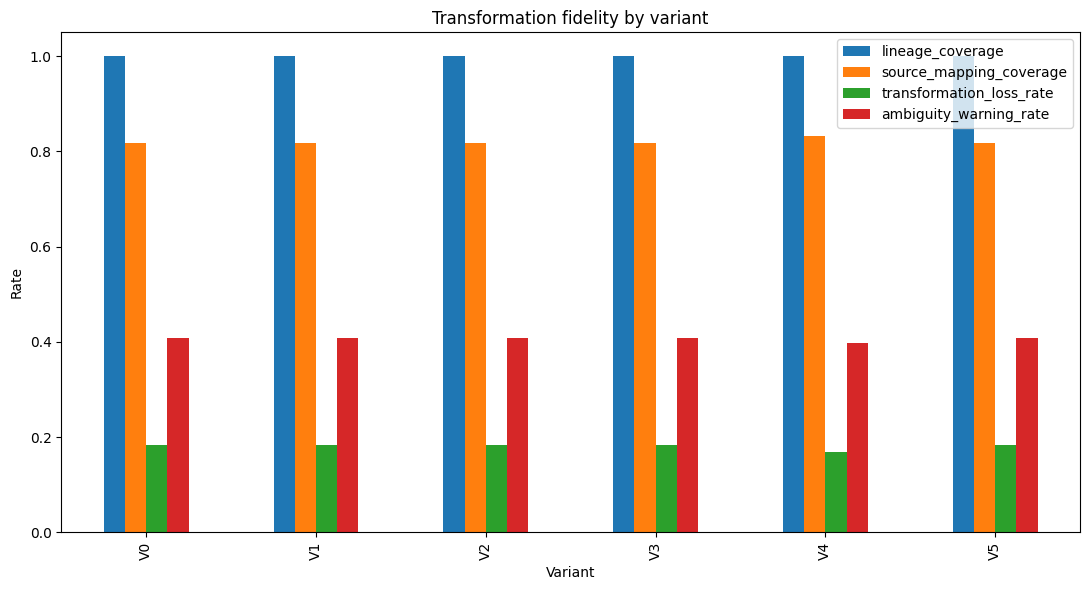

/content/ohdsi-fhir-omop-showcase-demo/figures/figure_tfl_fidelity_by_variant.png


In [36]:
overall_metrics = fidelity_metrics[
    (fidelity_metrics["source_resource_type"] == "ALL")
    &
    (fidelity_metrics["target_omop_table"] == "ALL")
].copy()

overall_metrics = (
    overall_metrics
    .set_index("variant")
    .reindex(["V0", "V1", "V2", "V3", "V4", "V5"])
)

ax = overall_metrics[
    [
        "lineage_coverage",
        "source_mapping_coverage",
        "transformation_loss_rate",
        "ambiguity_warning_rate",
    ]
].plot(
    kind="bar",
    figsize=(11, 6)
)

ax.set_xlabel("Variant")
ax.set_ylabel("Rate")
ax.set_ylim(0, 1.05)
ax.set_title("Transformation fidelity by variant")

plt.tight_layout()

figure3_path = FIG_DIR / "figure_tfl_fidelity_by_variant.png"

plt.savefig(
    figure3_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(figure3_path)

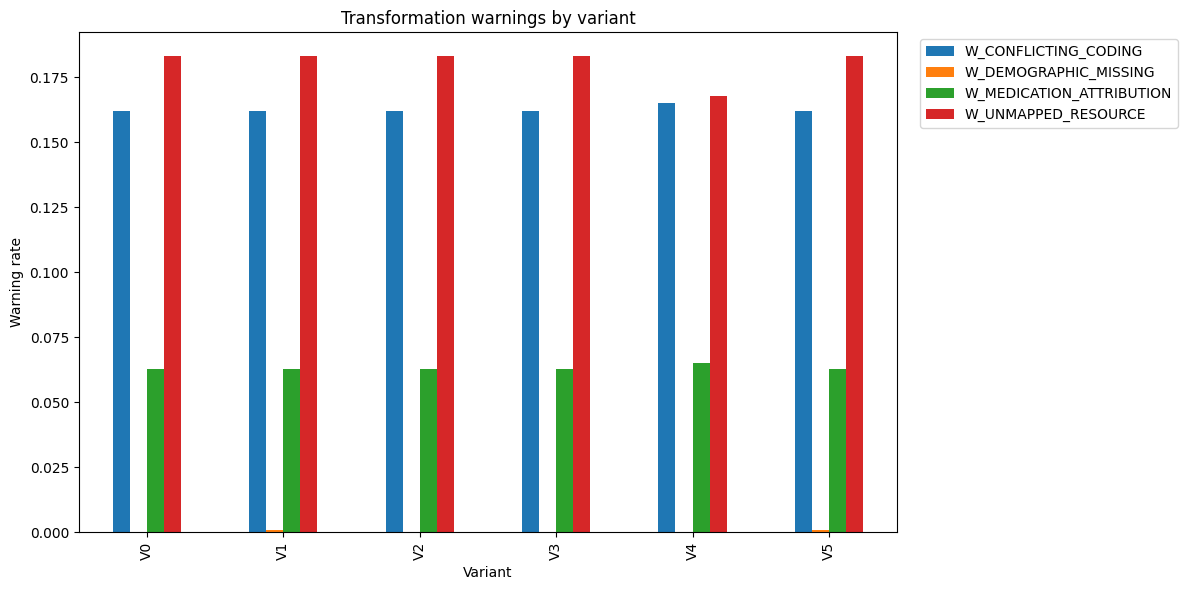

/content/ohdsi-fhir-omop-showcase-demo/figures/figure_tfl_warning_rates.png


In [37]:
warning_matrix = (
    warning_counts.pivot(
        index="variant",
        columns="warning_code",
        values="warning_rate"
    )
    .fillna(0)
    .reindex(["V0", "V1", "V2", "V3", "V4", "V5"])
)

ax = warning_matrix.plot(
    kind="bar",
    figsize=(12, 6)
)

ax.set_xlabel("Variant")
ax.set_ylabel("Warning rate")
ax.set_title("Transformation warnings by variant")
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

plt.tight_layout()

warning_figure_path = FIG_DIR / "figure_tfl_warning_rates.png"

plt.savefig(
    warning_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(warning_figure_path)

In [38]:
downstream_rows = []

v3_condition = distribution_summary[
    (distribution_summary["field"] == "condition_source")
    &
    (distribution_summary["variant"].isin(["V0", "V3"]))
][["variant", "jsd_vs_v0"]].copy()

for row in v3_condition.itertuples():
    downstream_rows.append({
        "measure": "Condition source JSD",
        "variant": row.variant,
        "value": row.jsd_vs_v0,
    })


v4_drug = cohort_summary[
    (cohort_summary["cohort"] == "drug")
    &
    (cohort_summary["variant"].isin(["V0", "V4"]))
][["variant", "variant_n"]].copy()

for row in v4_drug.itertuples():
    downstream_rows.append({
        "measure": "Drug-exposed persons",
        "variant": row.variant,
        "value": row.variant_n,
    })


downstream_figure_data = pd.DataFrame(
    downstream_rows
)

display(downstream_figure_data)

downstream_figure_data.to_csv(
    ANALYTICAL_OUT / "figure_downstream_data.csv",
    index=False
)

,measure,variant,value
0,Condition source JSD,V0,0.000000
1,Condition source JSD,V3,0.052355
2,Drug-exposed persons,V0,609.000000
3,Drug-exposed persons,V4,666.000000


# Phase J

## Public audit sample

In [39]:
def public_audit_sample(audit, n=100, seed=42):
    sample = audit.sample(
        min(n, len(audit)),
        random_state=seed
    ).copy()

    sample["source_resource_id_hash"] = sample[
        "source_resource_id"
    ].apply(
        lambda x: (
            hashlib.sha256(
                str(x).encode("utf-8")
            ).hexdigest()[:16]
            if not is_missing_value(x)
            else None
        )
    )

    drop_cols = [
        c for c in [
            "source_resource_id",
            "source_value_or_code",
        ]
        if c in sample.columns
    ]

    return sample.drop(columns=drop_cols)


public_samples = pd.concat(
    [
        public_audit_sample(
            TFL_AUDIT[v],
            n=100
        ).assign(variant=v)
        for v in ["V0", "V1", "V2", "V3", "V4", "V5"]
    ],
    ignore_index=True
)

display(public_samples.head(20))

public_samples.to_csv(
    FIDELITY_AUDIT_OUT / "tfl_public_audit_sample.csv",
    index=False
)

,transformation_id,variant,source_resource_type,source_reference_or_path,target_omop_table,target_omop_record_id,target_omop_field,mapping_rule_id,fidelity_status,warning_code,transformation_version,source_df_index,duplicate_source_id,is_mapping_event,target_link_method,source_resource_id_hash
0,7d13bfd0-73fb-56e1-a1c3-e4dd520caa3d,V0,Condition,abatementDateTime|clinicalStatus.coding.codes|...,condition_occurrence,14657,condition_concept_id|condition_end_date|condit...,Condition_to_condition_occurrence_r03,AMBIGUOUS,W_CONFLICTING_CODING,TFL-1.2|pyomop-6.4.0|fhiry-5.2.2,14656,False,True,fresh_empty_db_verified_rule_source_order,92bf25639df443f0
1,219dfd94-7023-547e-903e-a464453d8cfa,V0,Observation,code.coding.codes|effectiveDateTime|issued|pat...,observation,9271,observation_concept_id|observation_date|observ...,Observation_to_observation_r07,PRESERVED,,TFL-1.2|pyomop-6.4.0|fhiry-5.2.2,87532,False,True,fresh_empty_db_verified_rule_source_order,01a298ad4ada0623
2,5486c563-7fb1-5f75-ae15-eda57dba7269,V0,Observation,code.coding.codes|effectiveDateTime|issued|pat...,measurement,1054,measurement_concept_id|measurement_date|measur...,Observation_to_measurement_r06,PRESERVED,,TFL-1.2|pyomop-6.4.0|fhiry-5.2.2,79315,False,True,fresh_empty_db_verified_rule_source_order,7c116051f4e20645
3,a2a82338-7031-581e-bdfa-315b9c144770,V0,MedicationRequest,authoredOn|dosageInstruction|medicationCodeabl...,drug_exposure,11722,drug_concept_id|drug_exposure_end_date|drug_ex...,MedicationRequest_to_drug_exposure_r10,PRESERVED,,TFL-1.2|pyomop-6.4.0|fhiry-5.2.2,64983,False,True,fresh_empty_db_verified_rule_source_order,e5be02635973c3de
4,00dc89b1-1e0d-5b2f-a0c0-9e119b3eb7b4,V0,Observation,code.coding.codes|effectiveDateTime|issued|pat...,measurement,22302,measurement_concept_id|measurement_date|measur...,Observation_to_measurement_r06,PRESERVED,,TFL-1.2|pyomop-6.4.0|fhiry-5.2.2,100563,False,True,fresh_empty_db_verified_rule_source_order,fbad513ca8ea4690
5,895fbb3a-f67f-5629-849d-a0d9a8aa1055,V0,MedicationAdministration,None,None,<NA>,None,UNMAPPED_RESOURCE,UNMAPPED,W_UNMAPPED_RESOURCE,TFL-1.2|pyomop-6.4.0|fhiry-5.2.2,40175,False,False,None,3fd0548d7a94c9d3
6,eb5bb288-2228-52ef-bd99-600f9c57e4e4,V0,Observation,code.coding.codes|effectiveDateTime|issued|pat...,measurement,18180,measurement_concept_id|measurement_date|measur...,Observation_to_measurement_r06,PRESERVED,,TFL-1.2|pyomop-6.4.0|fhiry-5.2.2,96441,False,True,fresh_empty_db_verified_rule_source_order,1bbe2ab45179aeef
7,dddfb6be-e989-51b3-8ba3-e2e322335afa,V0,MedicationRequest,authoredOn|dosageInstruction|medicationCodeabl...,drug_exposure,6215,drug_concept_id|drug_exposure_end_date|drug_ex...,MedicationRequest_to_drug_exposure_r10,PRESERVED,,TFL-1.2|pyomop-6.4.0|fhiry-5.2.2,59476,False,True,fresh_empty_db_verified_rule_source_order,abac5538790158de
8,220472da-78e9-5b45-84fc-ea2a802fc1e5,V0,Observation,code.coding.codes|effectiveDateTime|issued|pat...,observation,7742,observation_concept_id|observation_date|observ...,Observation_to_observation_r07,PRESERVED,,TFL-1.2|pyomop-6.4.0|fhiry-5.2.2,86003,False,True,fresh_empty_db_verified_rule_source_order,307ea1d281af6c39
9,f516e588-c5db-5ca5-8a82-b5ee3a832246,V0,MedicationRequest,authoredOn|dosageInstruction|medicationCodeabl...,drug_exposure,9389,drug_concept_id|drug_exposure_end_date|drug_ex...,MedicationRequest_to_drug_exposure_r10,PRESERVED,,TFL-1.2|pyomop-6.4.0|fhiry-5.2.2,62650,False,True,fresh_empty_db_verified_rule_source_order,bb40562df5a0dec7


## Manifest

In [40]:
SOURCE_PATHS = globals().get("SOURCE_PATHS", {})

def sha256_file(path, chunk_size=1024 * 1024):
    h = hashlib.sha256()

    with open(path, "rb") as f:
        while True:
            block = f.read(chunk_size)

            if not block:
                break

            h.update(block)

    return h.hexdigest()


source_manifest_rows = []

for variant in ["V0", "V1", "V2", "V3", "V4", "V5"]:
    if variant == "V0" and V0_ORIGIN != "original_source":
        normalized_name = "V0_recovered_normalized.parquet"
    elif variant == "V5" and V5_ORIGIN != "original_source":
        normalized_name = "V5_constructed_normalized.parquet"
    else:
        normalized_name = f"{variant}_normalized.parquet"

    source_manifest_rows.append({
        "variant": variant,
        "source_path": (
            str(SOURCE_PATHS.get(variant))
            if variant in SOURCE_PATHS
            else None
        ),
        "normalized_path": str(
            NORMALIZED_DIR / normalized_name
        ),
        "source_rows": len(SOURCE_DF[variant]),
        "patient_rows": len(
            resource_subset(
                SOURCE_DF[variant],
                "Patient"
            )
        ),
        "v0_origin": V0_ORIGIN if variant == "V0" else None,
        "v5_origin": V5_ORIGIN if variant == "V5" else None,
    })


source_manifest = pd.DataFrame(
    source_manifest_rows
)

display(source_manifest)

source_manifest.to_csv(
    MAPPING_OUT / "source_manifest.csv",
    index=False
)


environment_manifest = {
    "python": sys.version,
    "platform": platform.platform(),
    "pyomop": getattr(pyomop, "__version__", "unknown"),
    "fhiry": getattr(fhiry, "__version__", "unknown"),
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "mapping_sha256": sha256_file(MAPPING_PATH),
    "transformation_version": TRANSFORMATION_VERSION,
    "fhiry_config": FHIRY_CONFIG,
    "v0_origin": V0_ORIGIN,
    "v5_origin": V5_ORIGIN,
}

with open(
    MAPPING_OUT / "environment_manifest.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        environment_manifest,
        f,
        indent=2
    )

print(
    json.dumps(
        environment_manifest,
        indent=2
    )
)

,variant,source_path,normalized_path,source_rows,patient_rows,v0_origin,v5_origin
0,V0,None,/content/drive/MyDrive/fhir_omop_colab/tfl_exe...,129333,1071,recovered_from_verified_unaffected_V1_V2_V3_V4...,None
1,V1,/content/drive/MyDrive/MyDrive fhir_omop_colab...,/content/drive/MyDrive/fhir_omop_colab/tfl_exe...,129333,1071,None,None
2,V2,/content/drive/MyDrive/MyDrive fhir_omop_colab...,/content/drive/MyDrive/fhir_omop_colab/tfl_exe...,129333,1071,None,None
3,V3,/content/drive/MyDrive/MyDrive fhir_omop_colab...,/content/drive/MyDrive/fhir_omop_colab/tfl_exe...,129333,1071,None,None
4,V4,/content/drive/MyDrive/MyDrive fhir_omop_colab...,/content/drive/MyDrive/fhir_omop_colab/tfl_exe...,126507,1071,None,None
5,V5,None,/content/drive/MyDrive/fhir_omop_colab/tfl_exe...,129333,1071,None,V0_with_V1_Patient_and_V3_Condition_rows


{
  "python": "3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]",
  "platform": "Linux-6.6.122+-x86_64-with-glibc2.35",
  "pyomop": "6.4.0",
  "fhiry": "5.2.2",
  "pandas": "2.2.2",
  "numpy": "2.0.2",
  "mapping_sha256": "a35ea4afa6a516c68441d704af5ccc6ed25871b9b20ded8463f6f5b8eb820456",
  "transformation_version": "TFL-1.2|pyomop-6.4.0|fhiry-5.2.2",
  "fhiry_config": {
    "REMOVE": [
      "text.div",
      "meta"
    ],
    "RENAME": {}
  },
  "v0_origin": "recovered_from_verified_unaffected_V1_V2_V3_V4_domains",
  "v5_origin": "V0_with_V1_Patient_and_V3_Condition_rows"
}


# Phase K

## Validation summary

In [41]:
validation_rows = []

validation_rows.append({
    "check": "V0 Patient resources",
    "passed": len(v0_patients) == 1071,
    "detail": f"{len(v0_patients)}",
})

validation_rows.append({
    "check": "V0 provenance resolved",
    "passed": V0_ORIGIN in {
        "original_source",
        "recovered_from_verified_unaffected_V1_V2_V3_V4_domains",
    },
    "detail": V0_ORIGIN,
})

validation_rows.append({
    "check": "Shared Patient population",
    "passed": bool(
        variant_checks["same_patient_population_as_v0"].all()
    ),
    "detail": (
        f"{int(variant_checks['same_patient_population_as_v0'].sum())}"
        f"/{len(variant_checks)} variants"
    ),
})


for variant, expected in EXPECTED_WARNINGS.items():
    sub = variant_validation[
        variant_validation["variant"] == variant
    ]

    validation_rows.append({
        "check": f"{variant} expected warning response",
        "passed": bool(
            len(sub)
            and sub["increased_vs_v0"].all()
        ),
        "detail": "; ".join(
            f"{r.expected_warning}: Δrate={r.delta_rate:.6f}"
            for r in sub.itertuples()
        ),
    })


overall = fidelity_metrics[
    (fidelity_metrics["source_resource_type"] == "ALL")
    &
    (fidelity_metrics["target_omop_table"] == "ALL")
]


validation_rows.append({
    "check": "TFL metrics generated for six variants",
    "passed": set(overall["variant"]) == {
        "V0", "V1", "V2", "V3", "V4", "V5"
    },
    "detail": ",".join(overall["variant"].tolist()),
})


validation_summary = pd.DataFrame(
    validation_rows
)

display(validation_summary)

validation_summary.to_csv(
    FIDELITY_METRIC_OUT / "tfl_validation_summary.csv",
    index=False
)

,check,passed,detail
0,V0 Patient resources,True,1071
1,V0 provenance resolved,True,recovered_from_verified_unaffected_V1_V2_V3_V4...
2,Shared Patient population,True,6/6 variants
3,V1 expected warning response,True,W_DEMOGRAPHIC_MISSING: Δrate=0.001043
4,V2 expected warning response,False,W_DUPLICATE_SOURCE_ID: Δrate=0.000000; W_TRACE...
5,V3 expected warning response,False,W_CONFLICTING_CODING: Δrate=0.000000
6,V4 expected warning response,True,W_MEDICATION_ATTRIBUTION: Δrate=0.002200
7,V5 expected warning response,False,W_DEMOGRAPHIC_MISSING: Δrate=0.001043; W_CONFL...
8,TFL metrics generated for six variants,True,"V0,V1,V2,V3,V4,V5"


## Export

In [42]:
PACKAGE_DIR = Path("/content/tfl_v8_public_package")

if PACKAGE_DIR.exists():
    shutil.rmtree(PACKAGE_DIR)

PACKAGE_DIR.mkdir(parents=True)


for folder in [
    MAPPING_OUT,
    FIDELITY_AUDIT_OUT,
    FIDELITY_METRIC_OUT,
    ANALYTICAL_OUT,
]:
    target = PACKAGE_DIR / folder.name
    target.mkdir(parents=True, exist_ok=True)

    for p in folder.glob("*"):
        if p.is_file():
            shutil.copy2(p, target / p.name)


figure_target = PACKAGE_DIR / "figures"
figure_target.mkdir(parents=True, exist_ok=True)

for p in FIG_DIR.glob("figure_tfl_*.png"):
    shutil.copy2(p, figure_target / p.name)


zip_path = shutil.make_archive(
    "/content/FHIRy_pyOMOP_TFL_v8_public_outputs",
    "zip",
    PACKAGE_DIR
)

print("Package:", zip_path)
print("Private audits:", AUDIT_DIR)
print("Fresh databases:", DB_DIR)
print("Repository outputs:", OUT_ROOT)

Package: /content/FHIRy_pyOMOP_TFL_v8_public_outputs.zip
Private audits: /content/drive/MyDrive/fhir_omop_colab/tfl_execution_v6/fidelity_audit
Fresh databases: /content/drive/MyDrive/fhir_omop_colab/tfl_execution_v6/fresh_omop
Repository outputs: /content/ohdsi-fhir-omop-showcase-demo/outputs
